In [34]:
import sys

sys.path.append("..")
from src import *

# Visually Proving Temporal dynamics are preserved
This notebook is used to show that Freq2Clean preserves DeepCAD's temporal dynamics.

In [35]:
max_frames = None
dataset = "synthetic"
variant = 15
segment_net = "suite2p"

In [ ]:
meta = DATASETS[dataset]

x = Recording(meta.x, max_frames=max_frames).normalized
y_dcad = Recording(f"dataset/{dataset}/deepcad_{variant}/data.tiff", max_frames=max_frames).normalized
y_f2c = Recording(
    f"../5-freq2clean/results/synthetic/deepcad_15/20251118-1205-synthetic_deepcad_15.tiff", max_frames=max_frames
).np
gt = Recording(meta.gt, max_frames=max_frames).normalized

In [37]:
masks_dcad = np.load(f"{segment_net}_results/{dataset}/deepcad_{variant}/mask.npy")
masks_f2c = np.load(f"{segment_net}_results/{dataset}/fft_{variant}/mask.npy")
masks_gt = np.load(f"{segment_net}_results/{dataset}/gt/mask.npy")
ious_dcad = np.load(f"{segment_net}_results/{dataset}/deepcad_{variant}/ious.npy")
ious_f2c = np.load(f"{segment_net}_results/{dataset}/fft_{variant}/ious.npy")

In [38]:
class ROI:
    def __init__(self, label, coords: tuple[np.array, np.array], mask):
        self.label = int(label)
        self.coords = np.vstack(coords).T
        self.ys, self.xs = coords
        self.centroid = (self.ys.mean(), self.xs.mean())
        self.area = self.ys.size
        self.mask = mask


def masks2rois(masks: np.ndarray) -> list[ROI]:
    return [ROI(i, np.nonzero(mask), mask) for i, mask in enumerate(masks)]


def get_traces(vid: np.ndarray, rois: list[ROI]) -> np.ndarray:
    return np.array([vid[:, r.ys[:], r.xs[:]].mean(axis=1) for r in rois])


def get_traces_for_one_roi(vid: np.ndarray, roi: ROI) -> np.ndarray:
    sorted_coords = sorted(
        zip(roi.ys, roi.xs),
        key=lambda coords: ((coords[0] - roi.centroid[0]) ** 2 + (coords[1] - roi.centroid[1]) ** 2),
    )
    return np.array([vid[:, x, y] for y, x in sorted_coords])

In [39]:
gt_rois = masks2rois(masks_gt)

In [44]:
sort_by_pos = lambda roi: (roi.centroid[0] ** 2 + roi.centroid[1] ** 2) ** 0.5
sort_by_size = lambda roi: -len(roi.xs)
gt_rois = sorted(gt_rois, key=sort_by_size)

## All rois analyzer

In [100]:
traces_x = get_traces(x, gt_rois)
traces_dcad = get_traces(y_dcad, gt_rois)
traces_f2c = get_traces(y_f2c, gt_rois)
traces_gt = get_traces(gt, gt_rois)

In [101]:
sort_by_strength = lambda i: np.sum(traces_gt[i])
sort_by_nothing = lambda i: 1
sorted_idxs = sorted(range(len(gt_rois)), key=sort_by_nothing)

traces_x = np.array([(t - t.min()) / (t.max() - t.min()) for t in traces_x])[sorted_idxs]
traces_dcad = np.array([ (t-t.min())/(t.max()-t.min()) for t in traces_dcad])[sorted_idxs]
traces_f2c = np.array([ (t-t.min())/(t.max()-t.min()) for t in traces_f2c])[sorted_idxs]
traces_gt = np.array([ (t-t.min())/(t.max()-t.min()) for t in traces_gt])[sorted_idxs]

Noisy input


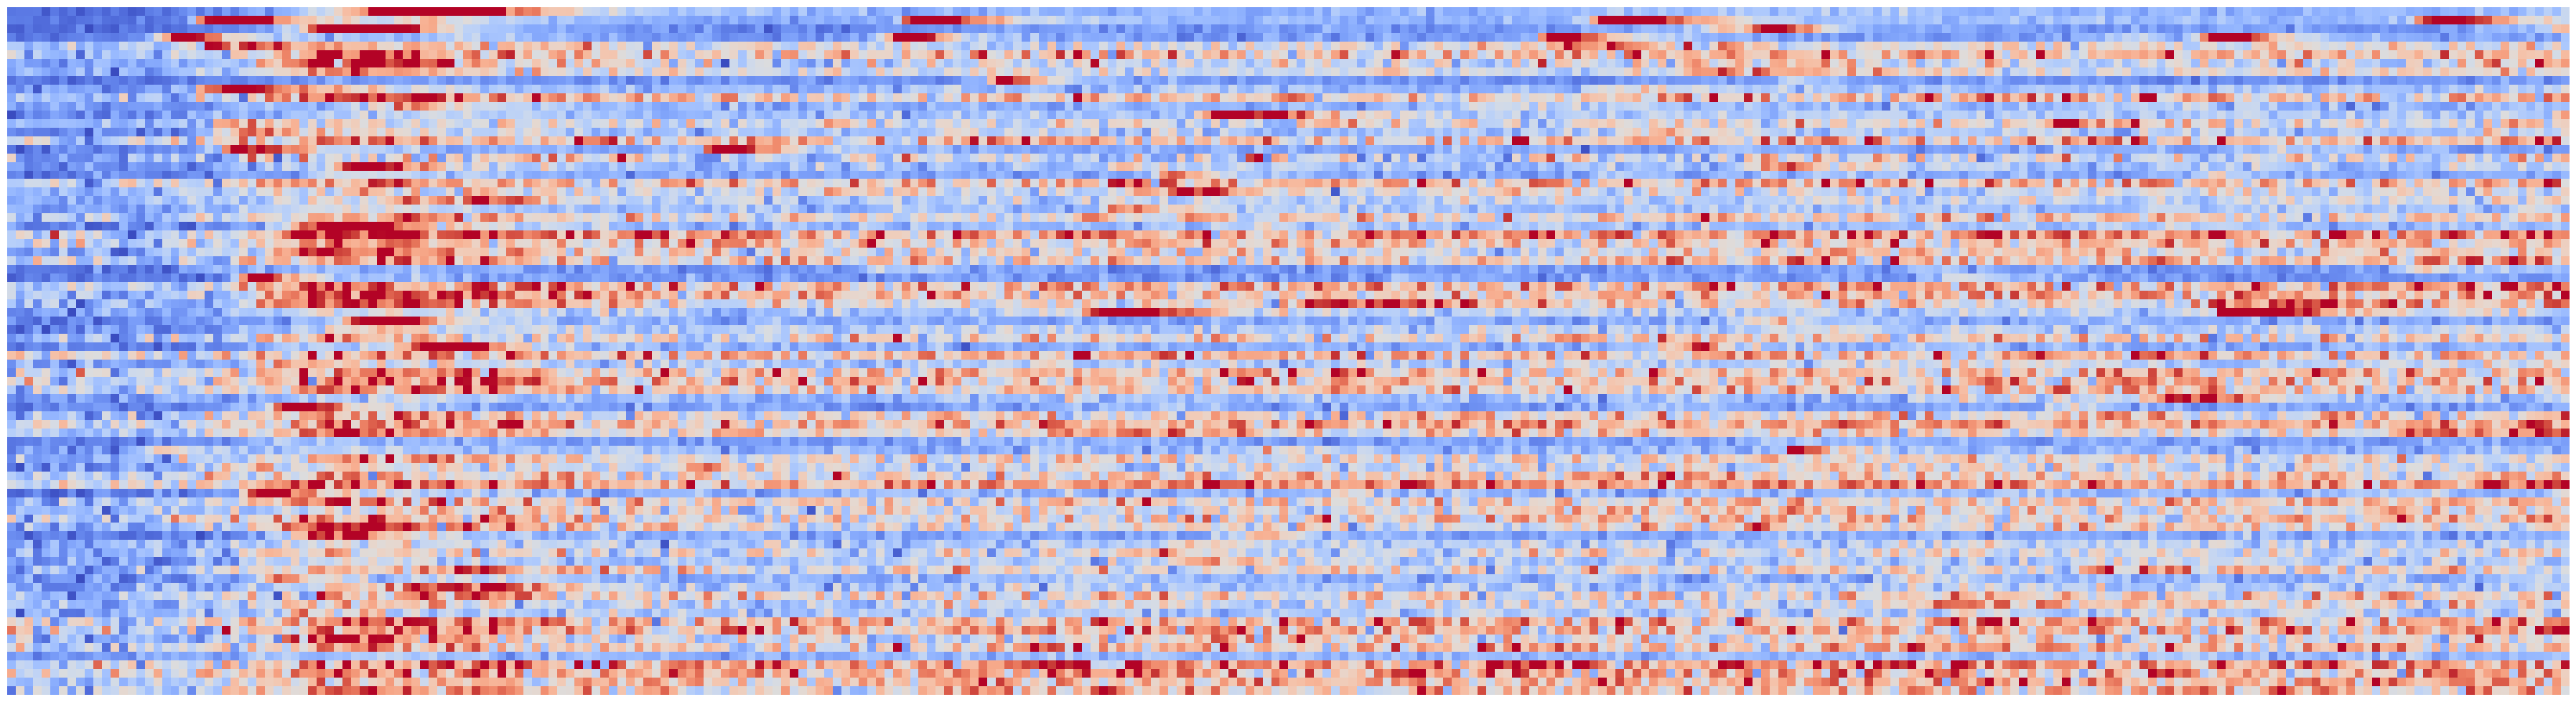

DeepCAD-RT


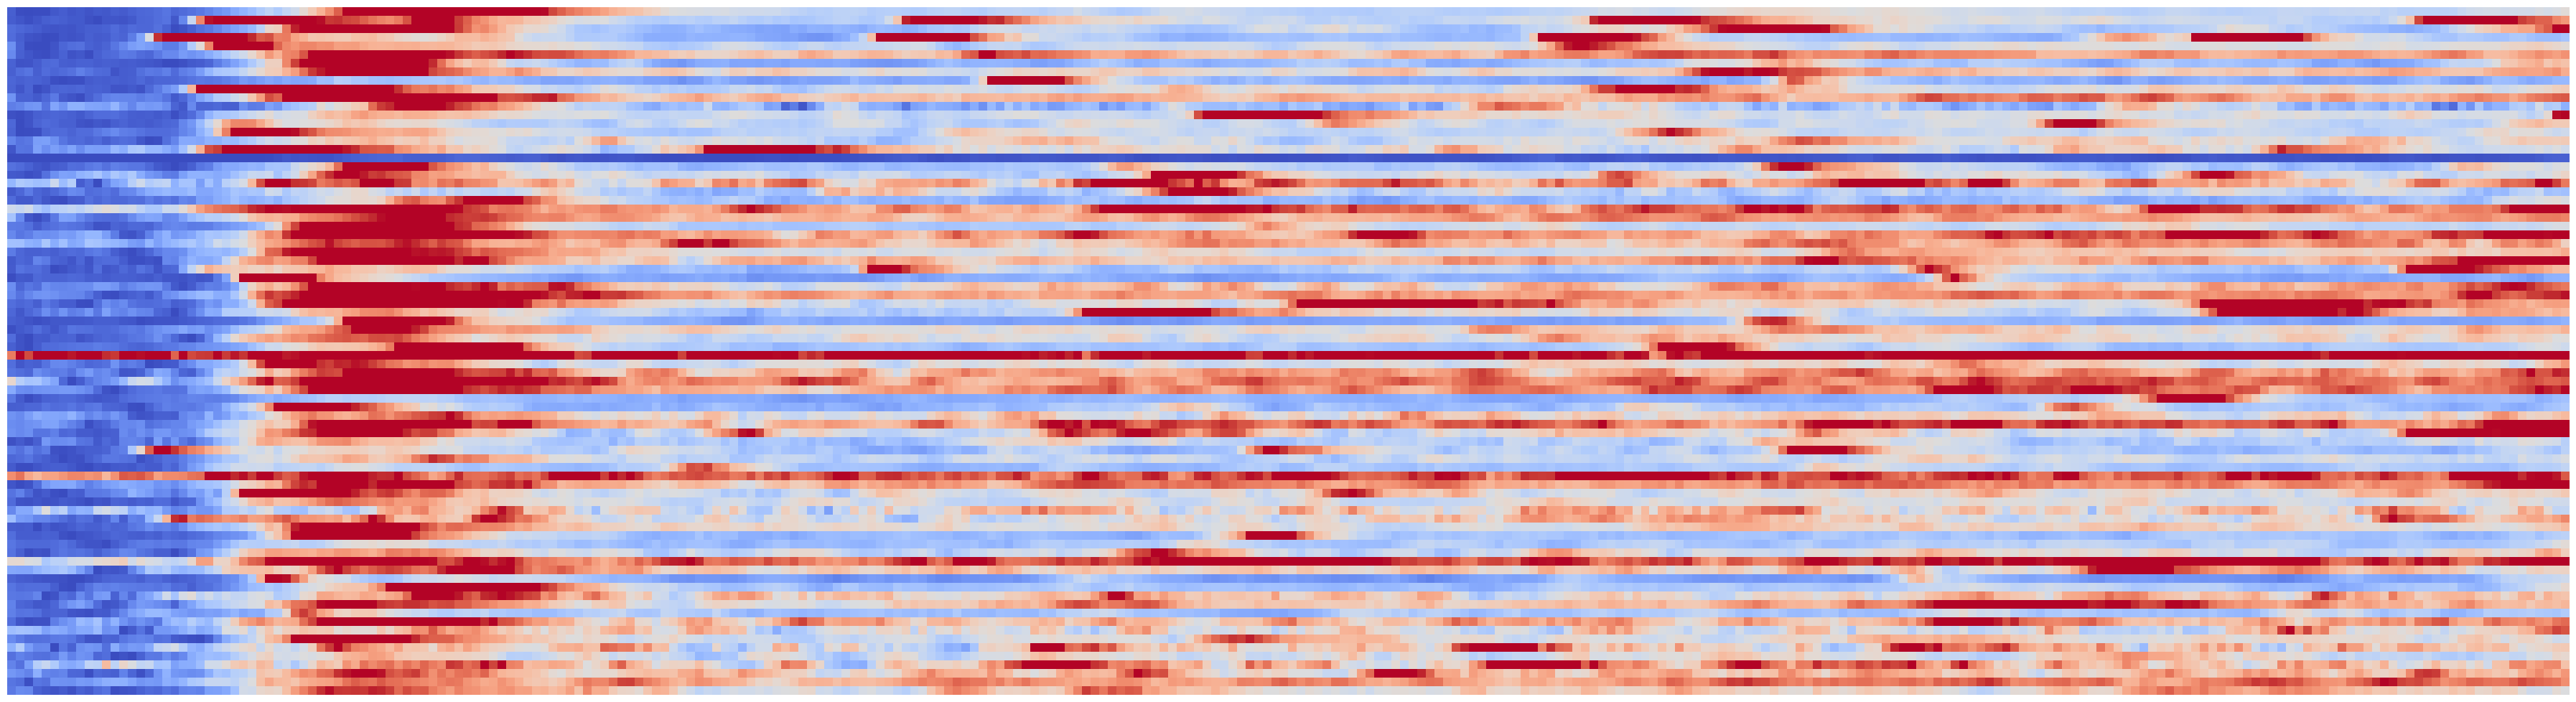

Freq2Clean


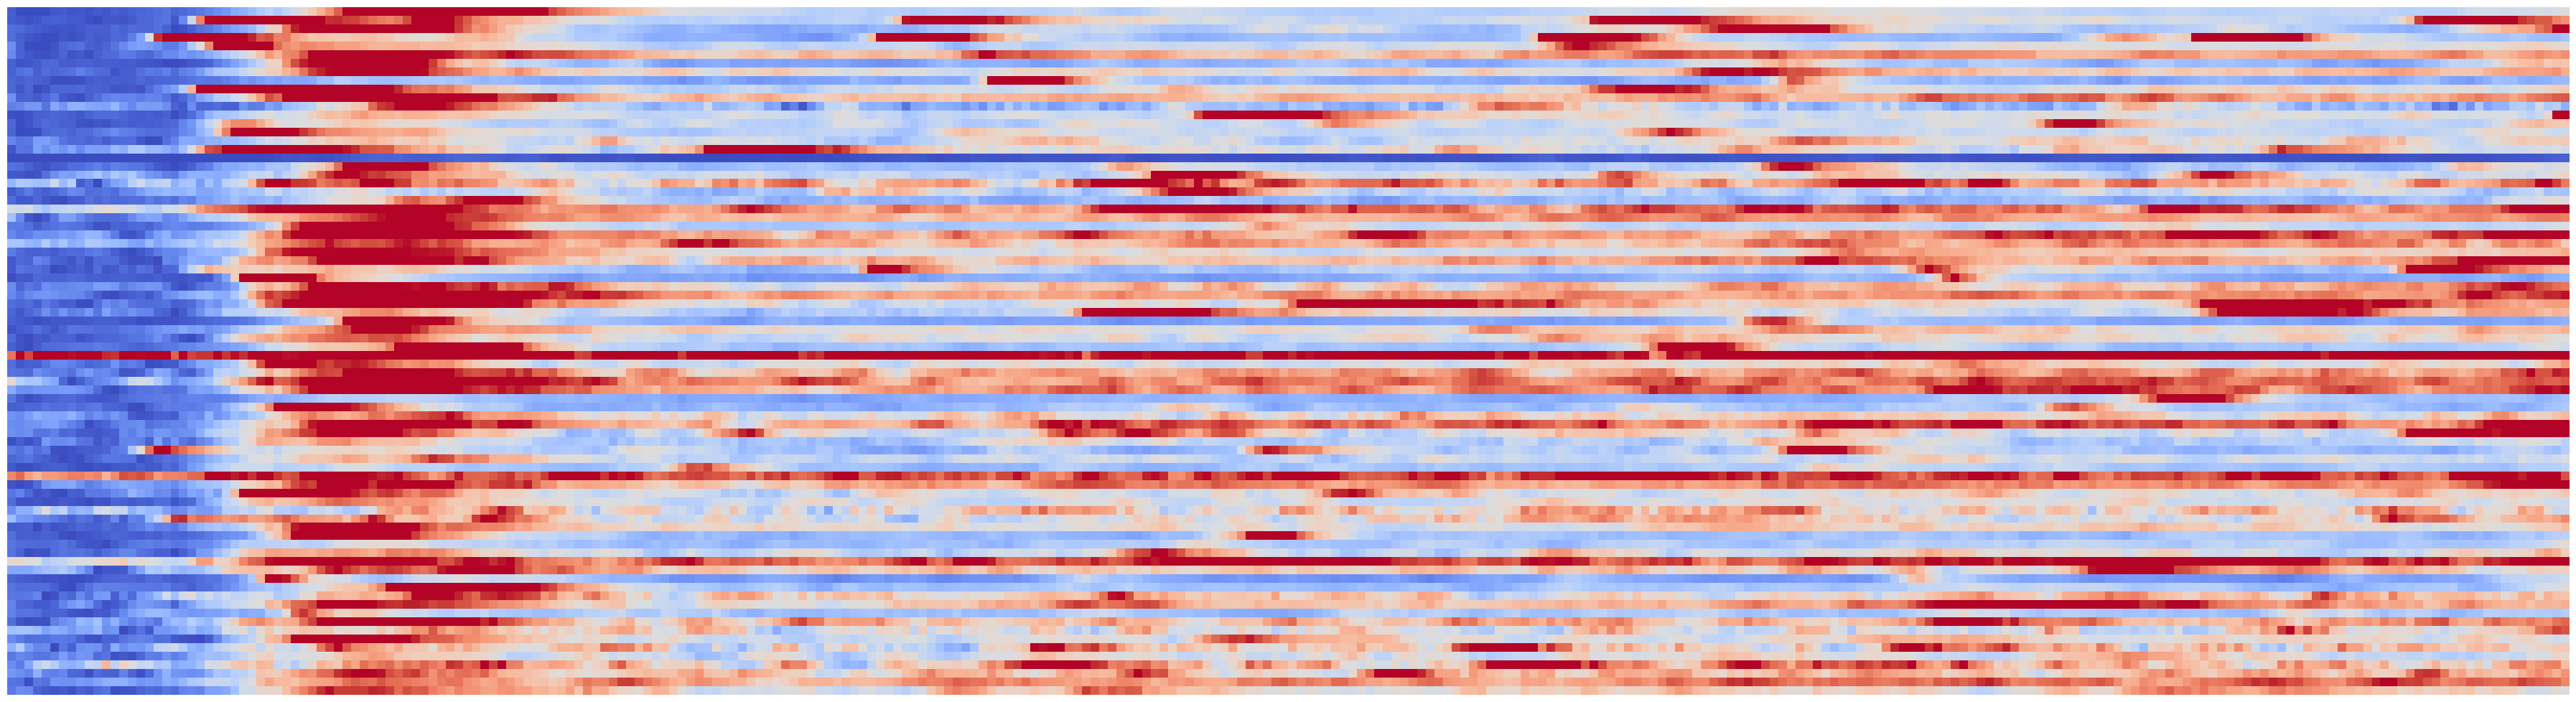

Ground Truth


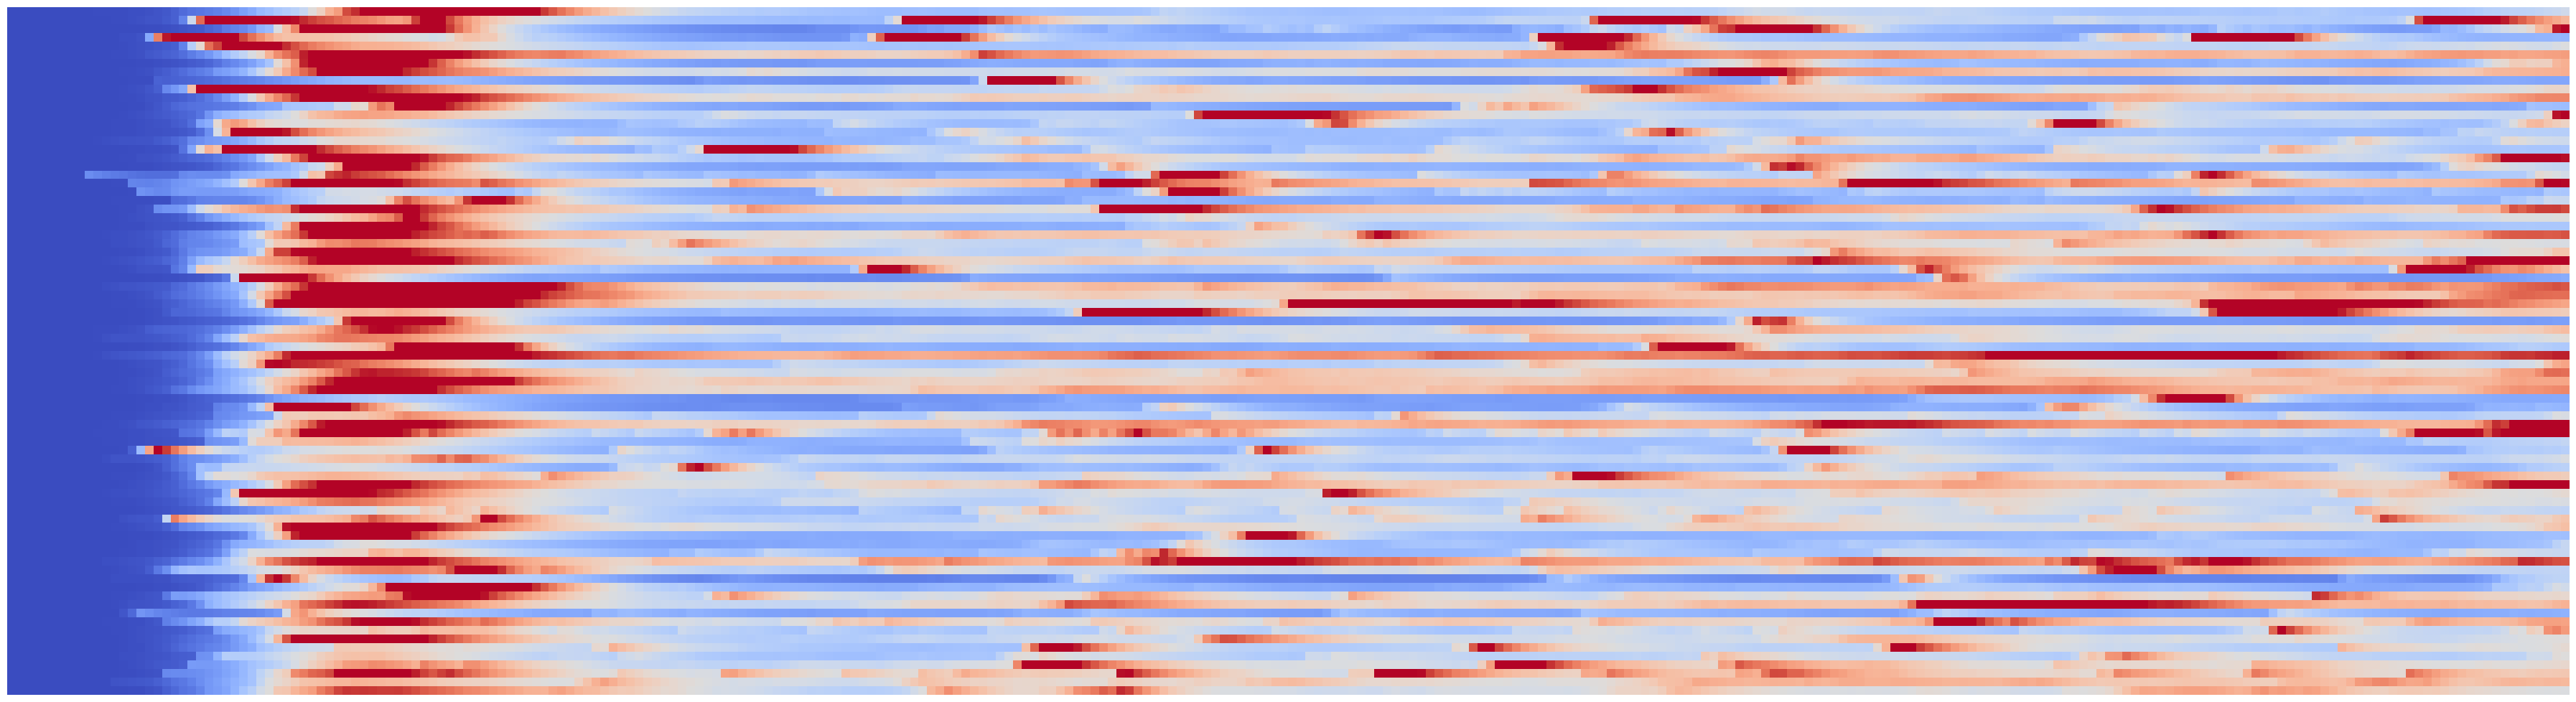

In [102]:
max_t = 1500
step = 5
cmap = "coolwarm"
max_rois = 80
vrange = (0, 0.7)

cprint("green:Noisy input")
imshow(traces_x[:max_rois, 10:max_t:step], size=40, cmap=cmap, vrange=vrange)

cprint("green:DeepCAD-RT")
imshow(traces_dcad[:max_rois, 10:max_t:step], size=40, cmap=cmap, vrange=vrange)

cprint("green:Freq2Clean")
imshow(traces_f2c[:max_rois, 10:max_t:step], size=40, cmap=cmap, vrange=vrange)

cprint("green:Ground Truth")
imshow(traces_gt[:max_rois, 10:max_t:step], size=40, cmap=cmap, vrange=vrange)

### Traces plotting

In [155]:
series_x = traces_x[:max_rois, 10 : max_t // 2 : 1]
series_dcad = traces_dcad[:max_rois, 10 : max_t // 2 : 1]
series_f2c = traces_f2c[:max_rois, 10 : max_t // 2 : 1]
series_gt = traces_gt[:max_rois, 10 : max_t // 2 : 1]

In [156]:
sort_by_max = lambda i: -np.max(series_gt[i])
sorted_idxs = sorted(range(len(series_gt)), key=sort_by_max)
series_x = series_x[sorted_idxs]
series_dcad = series_dcad[sorted_idxs]
series_f2c = series_f2c[sorted_idxs]
series_gt = series_gt[sorted_idxs]

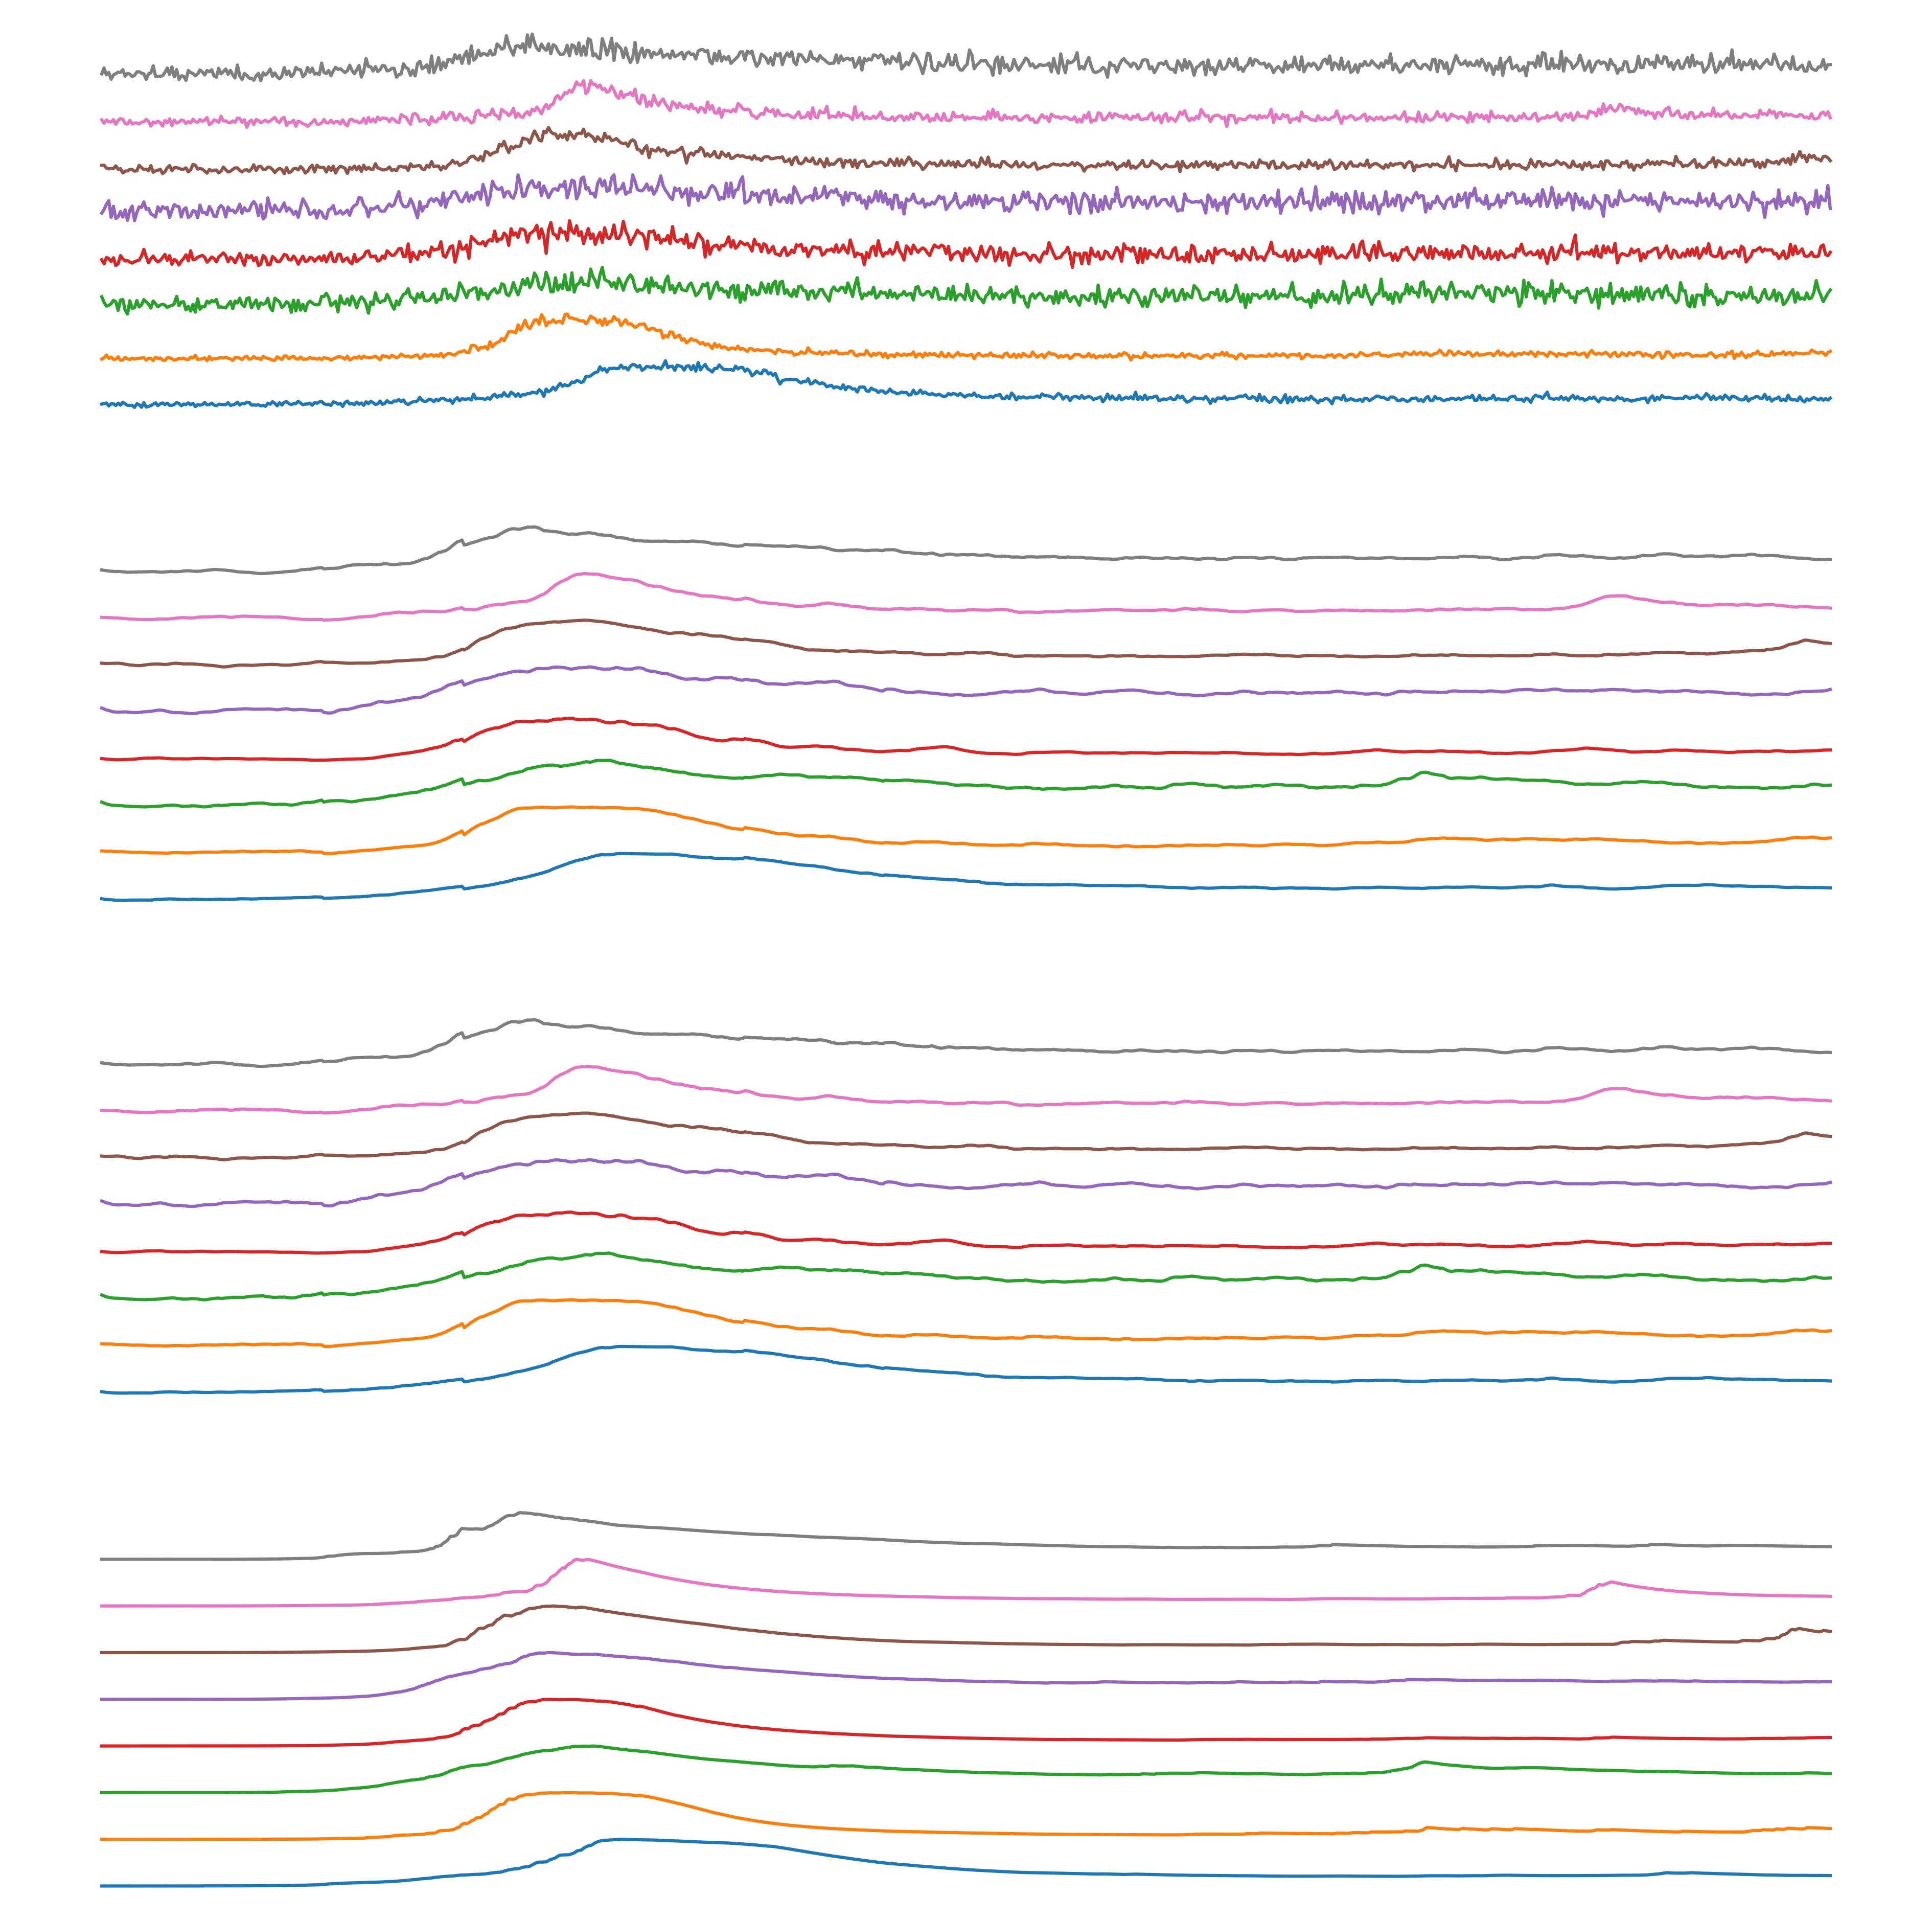

In [180]:
fig, axs = plt.subplots(4, 1, figsize=(16, 16), dpi=300)
for idx, i in enumerate([0,1,2,3,4,10,7,11]):
    pd.Series(series_x[i]+idx).plot(ax=axs[0])
    pd.Series(series_dcad[i]+idx).plot(ax=axs[1])
    pd.Series(series_f2c[i]+idx).plot(ax=axs[2])
    pd.Series(series_gt[i]+idx).plot(ax=axs[3])
for ax in axs:
    ax.set_axis_off()

### Neuron cropping

8, 11, 16, 21

In [225]:
def roi2crop(vid, roi, crop_size=50):
    return vid[
    :,
    int(roi.centroid[0]) - crop_size // 2 : int(roi.centroid[0]) + crop_size // 2,
    int(roi.centroid[1]) - crop_size // 2 : int(roi.centroid[1]) + crop_size // 2,
]

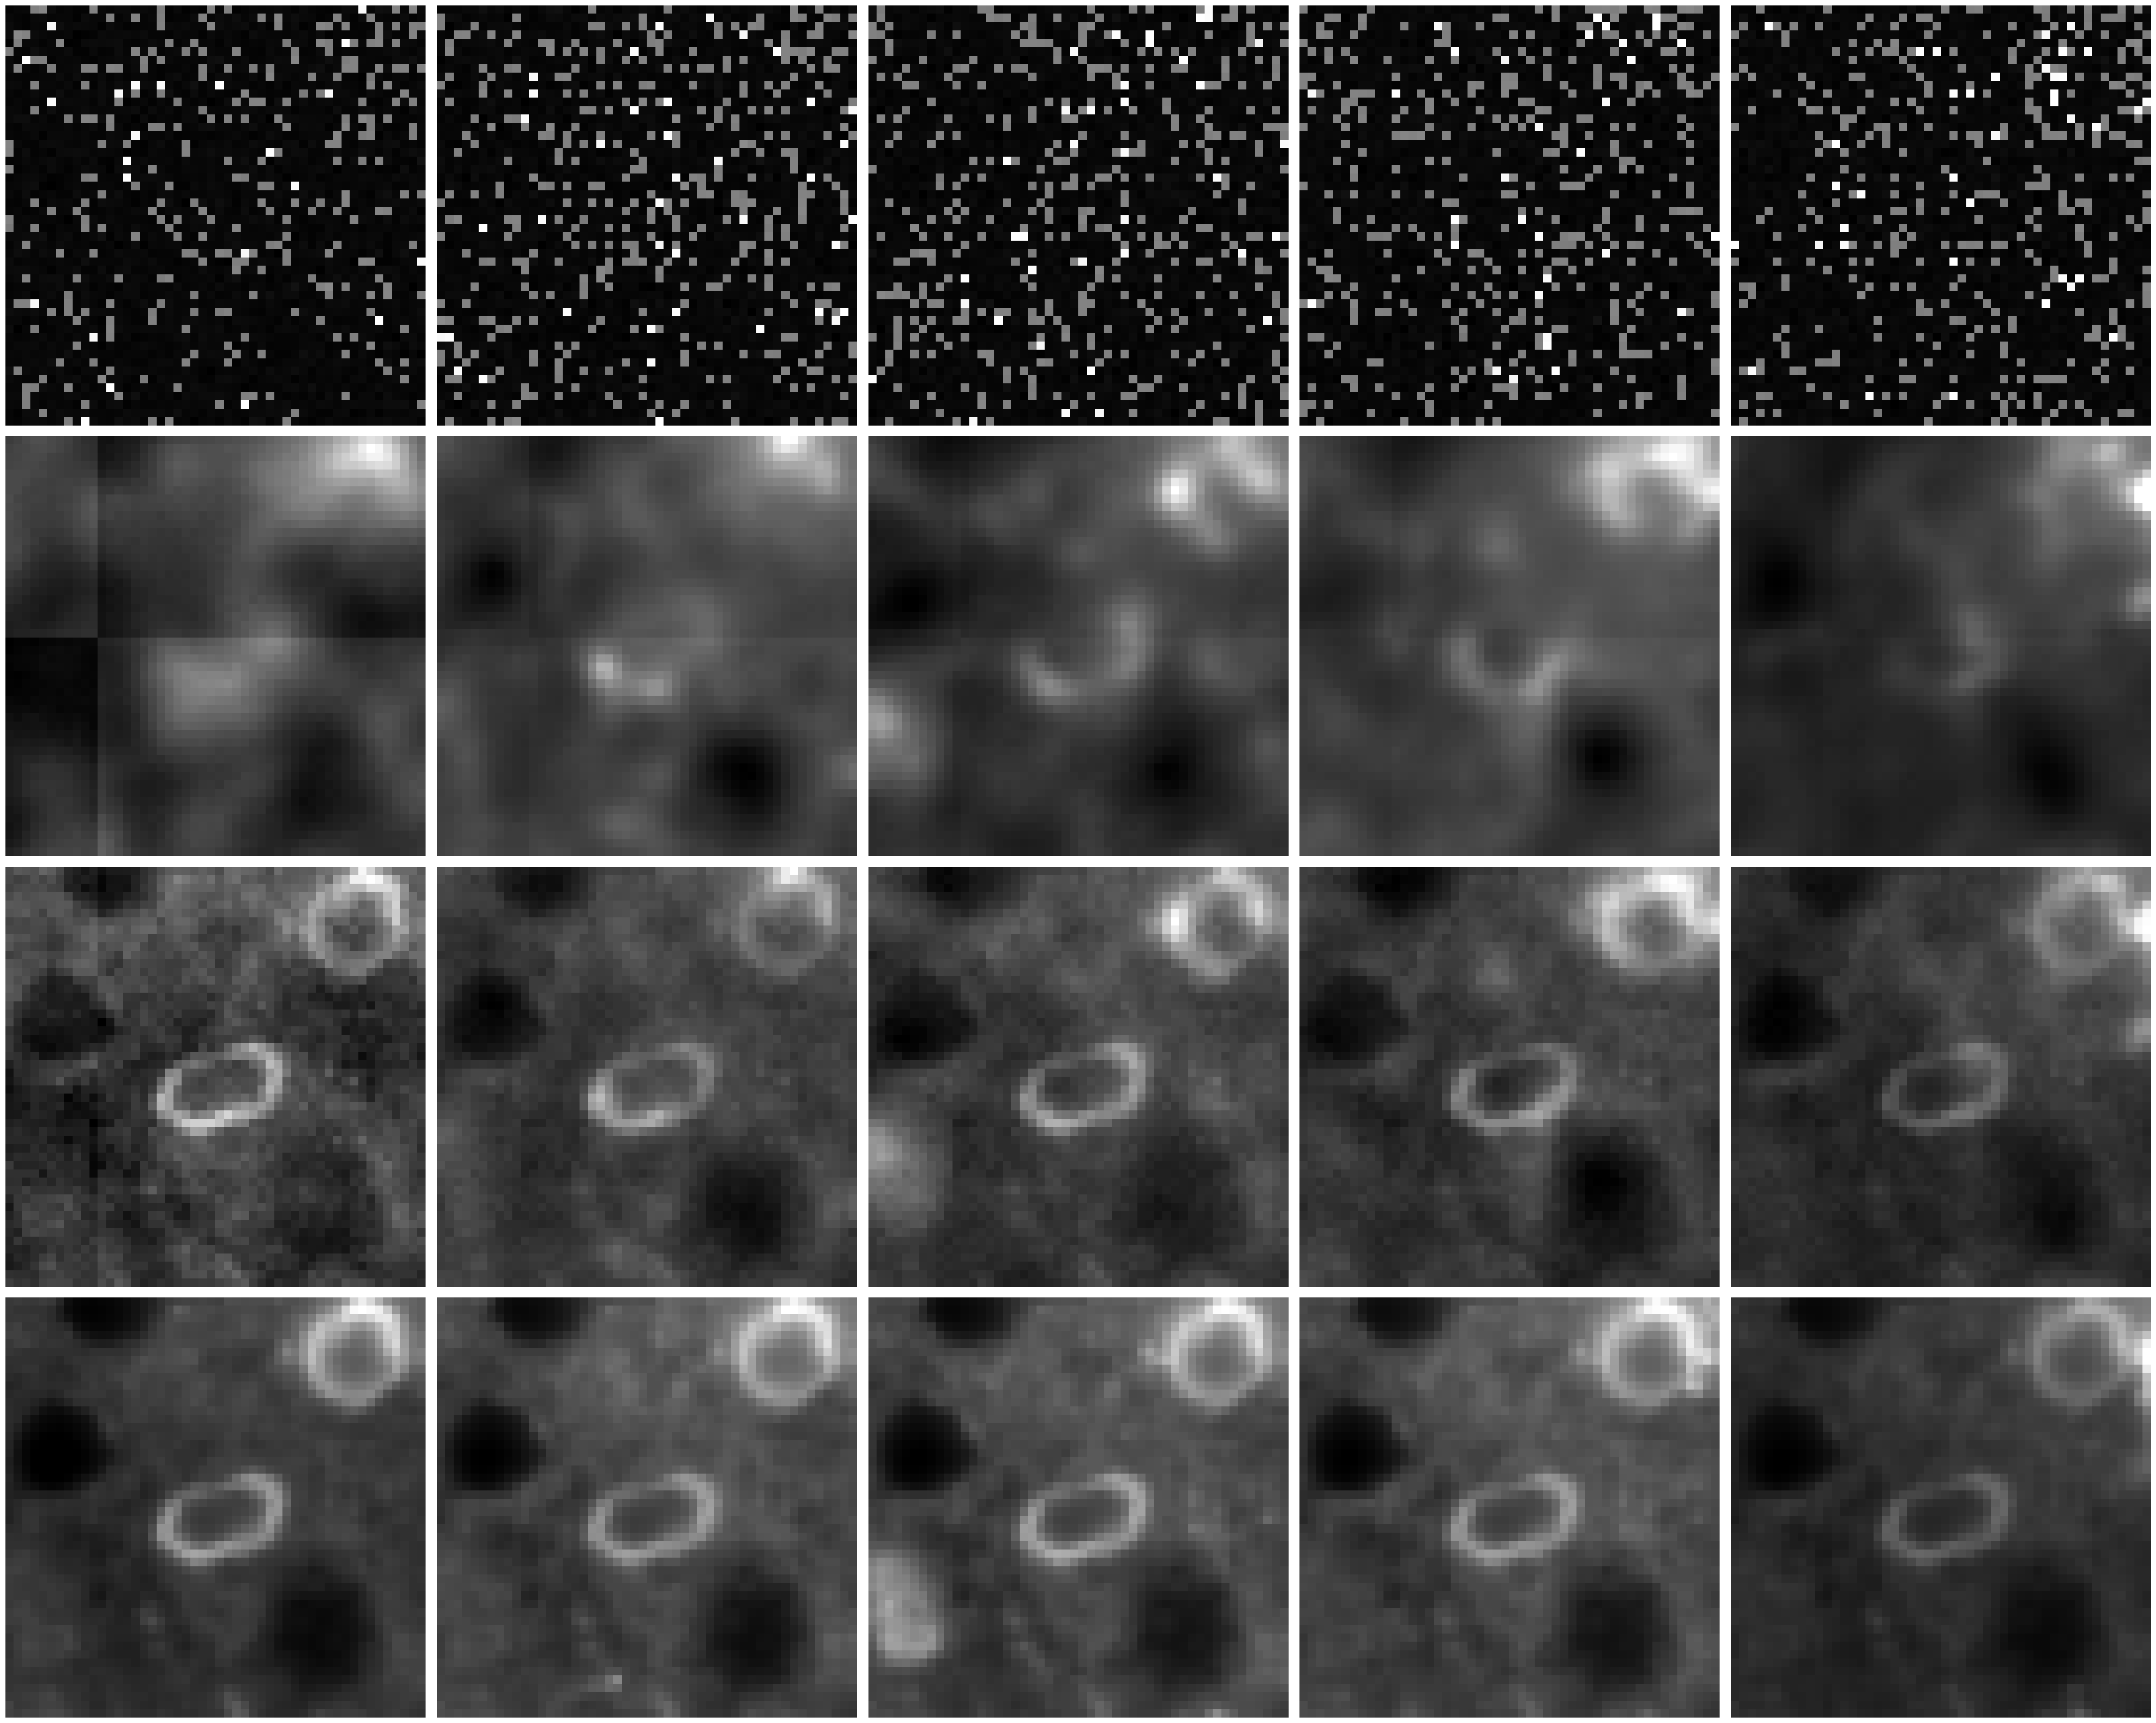

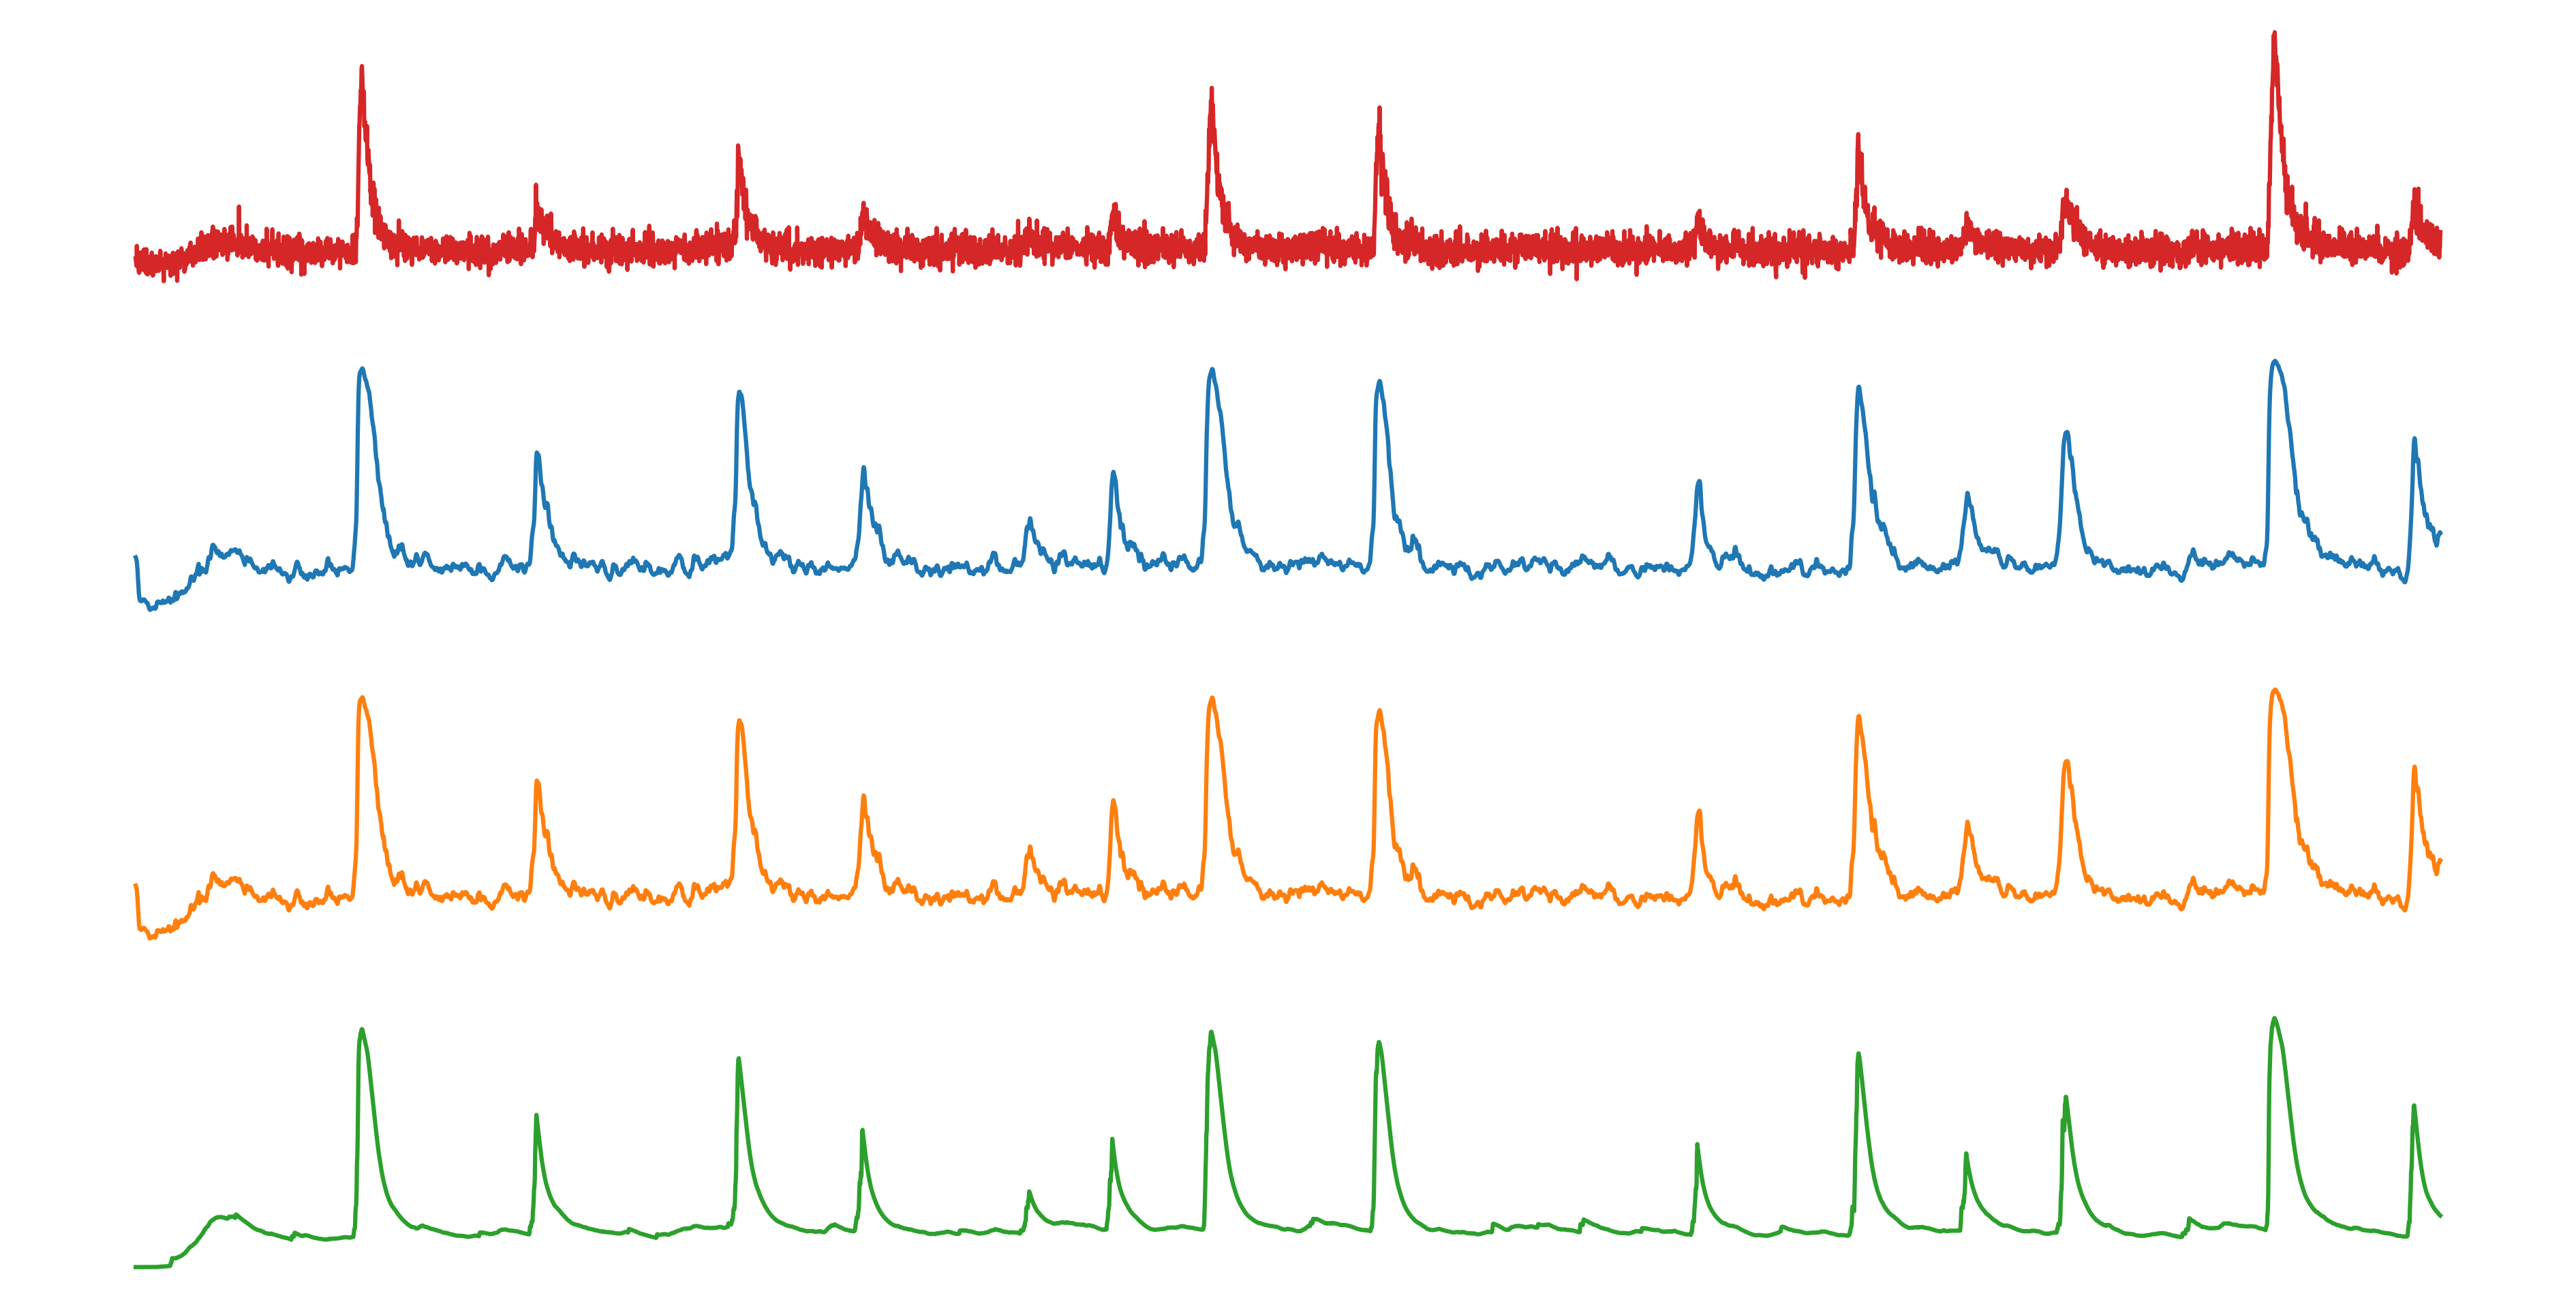

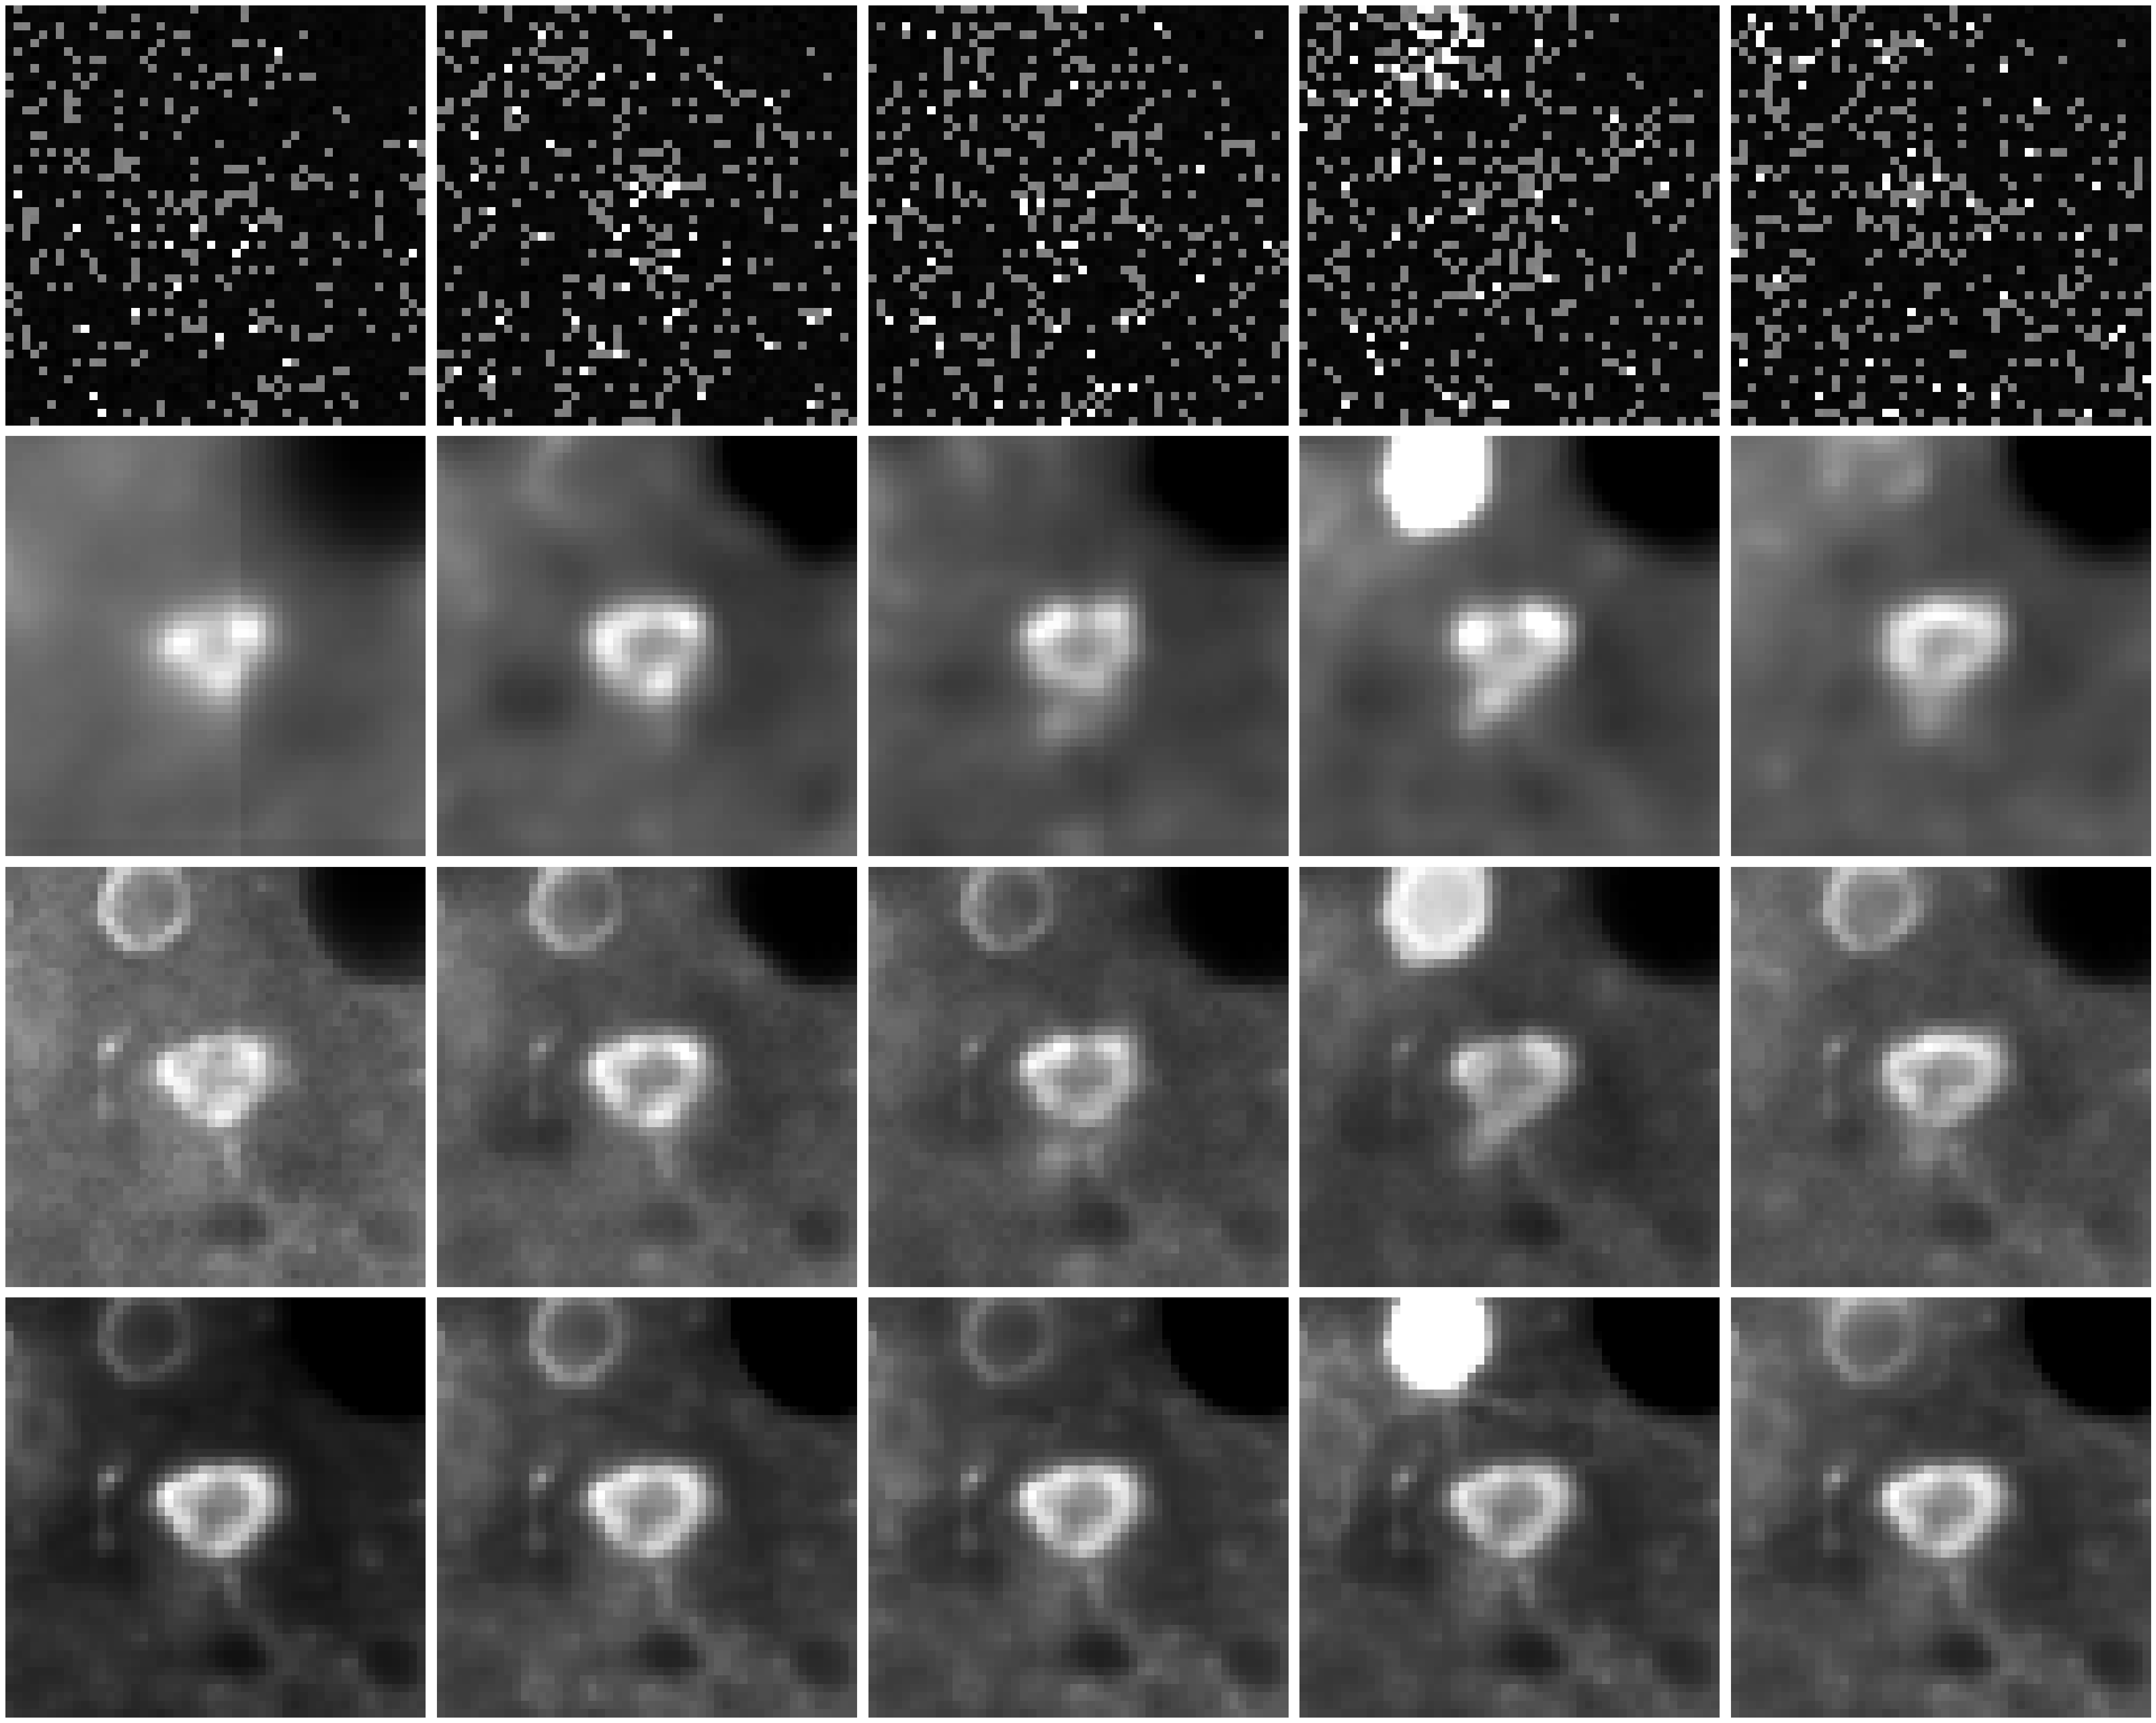

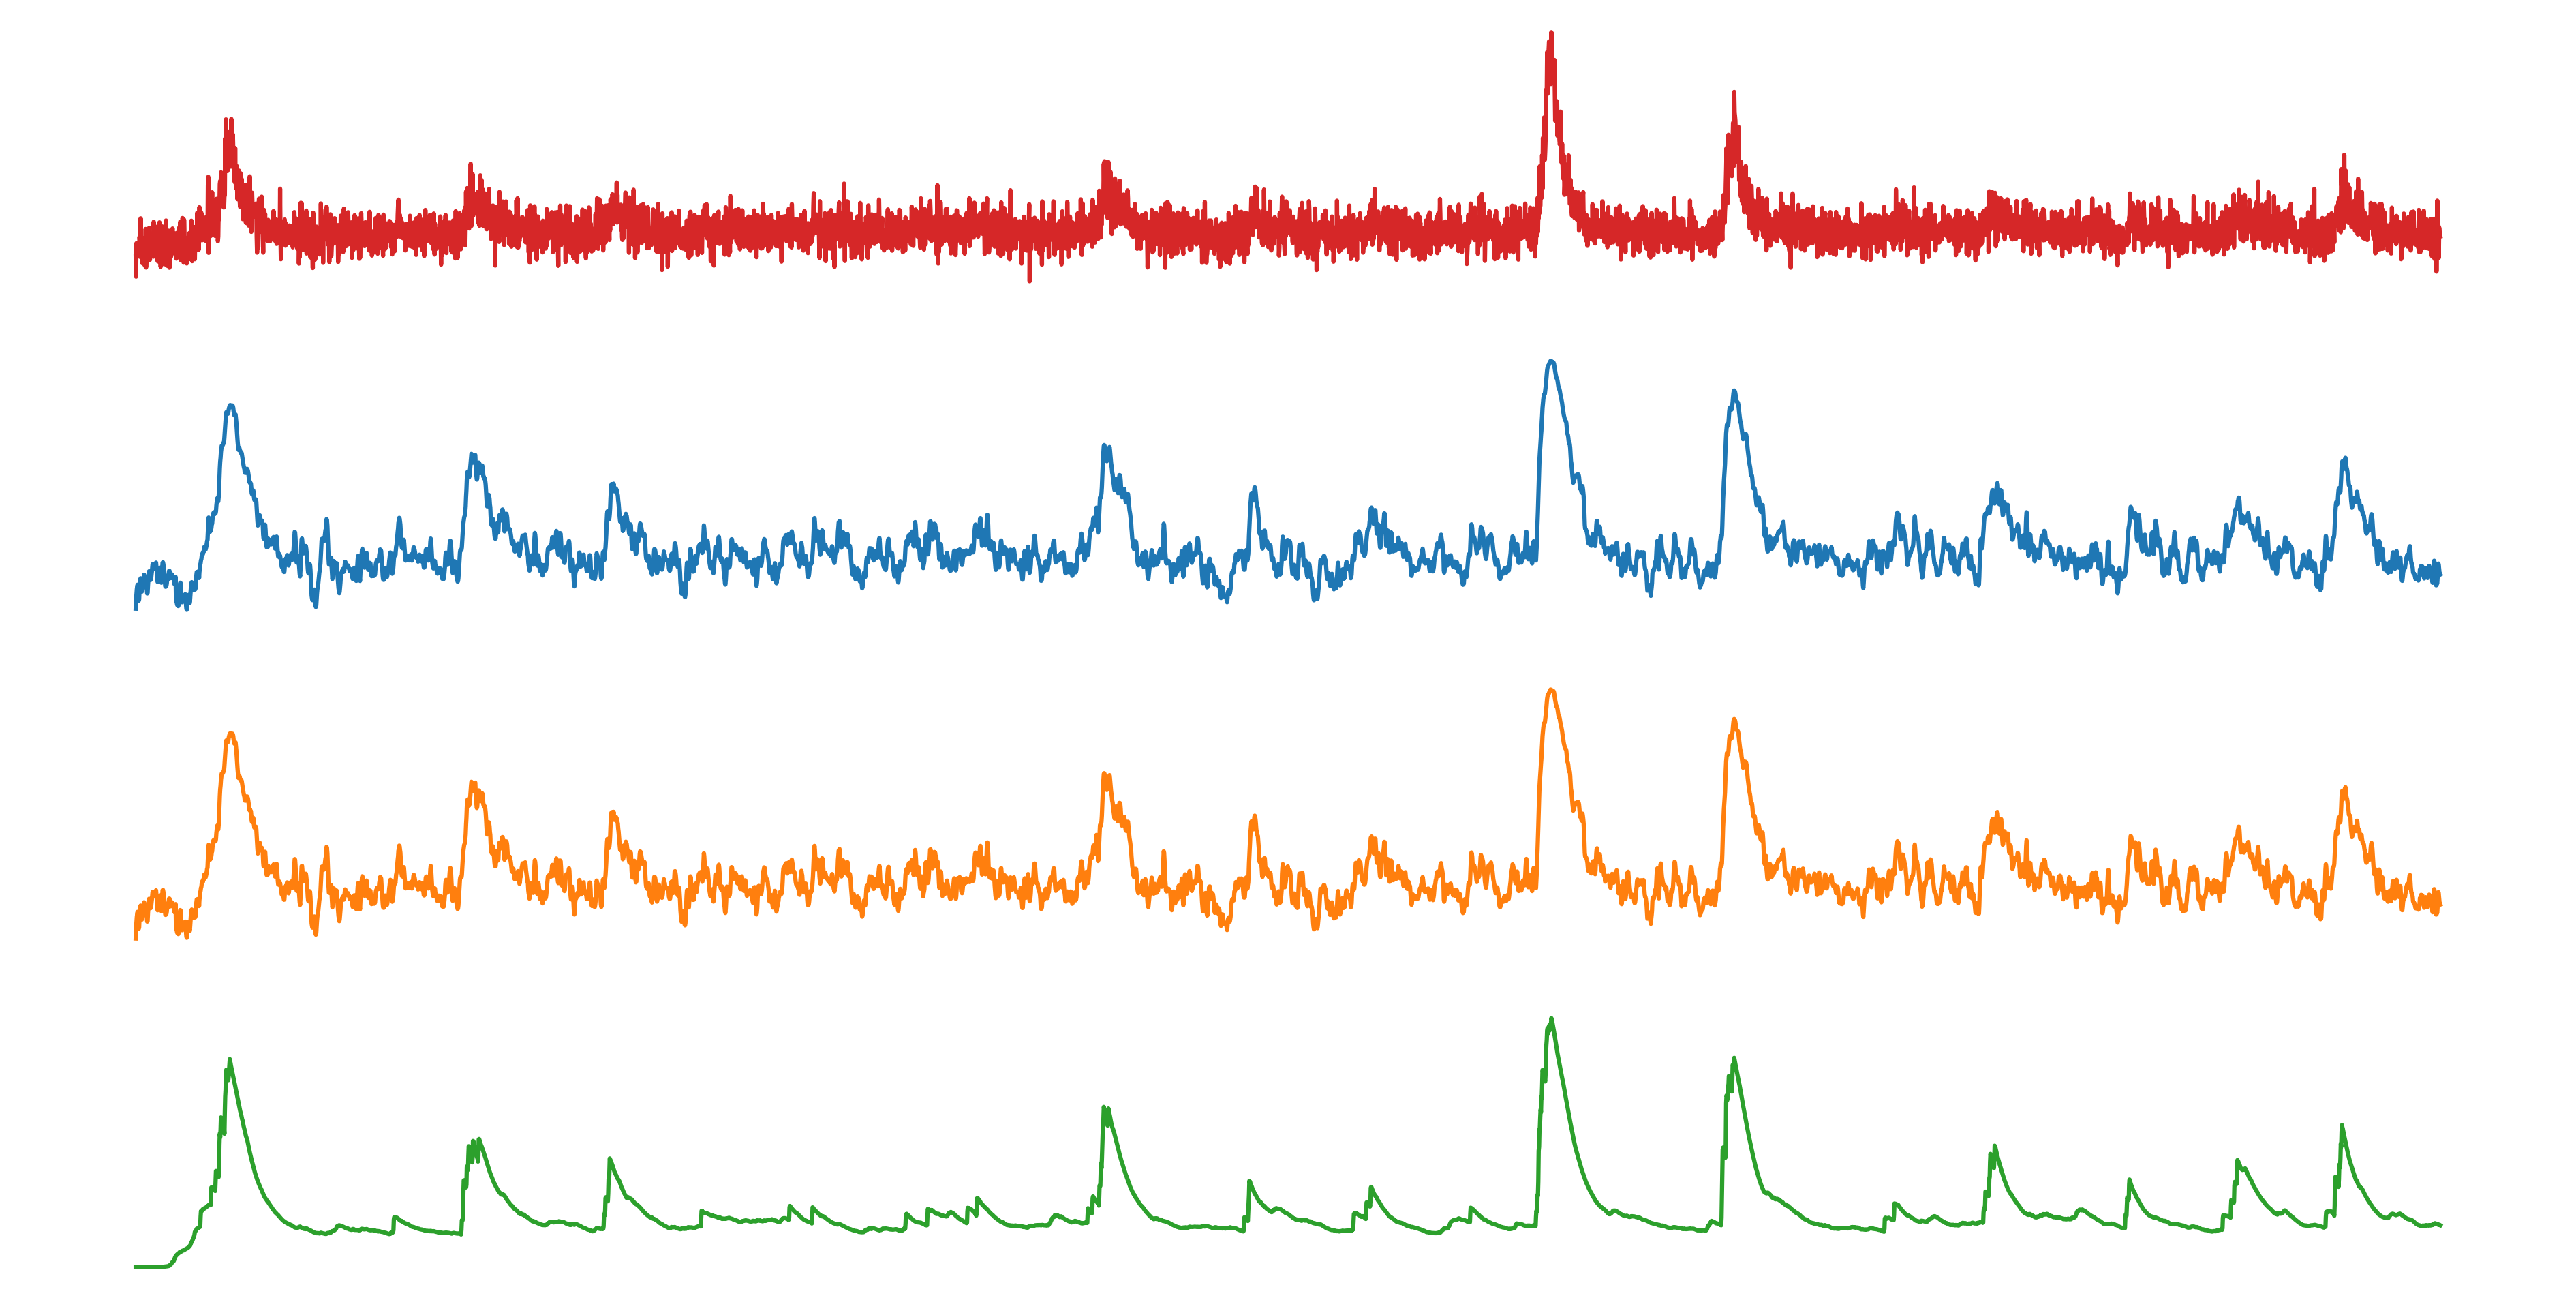

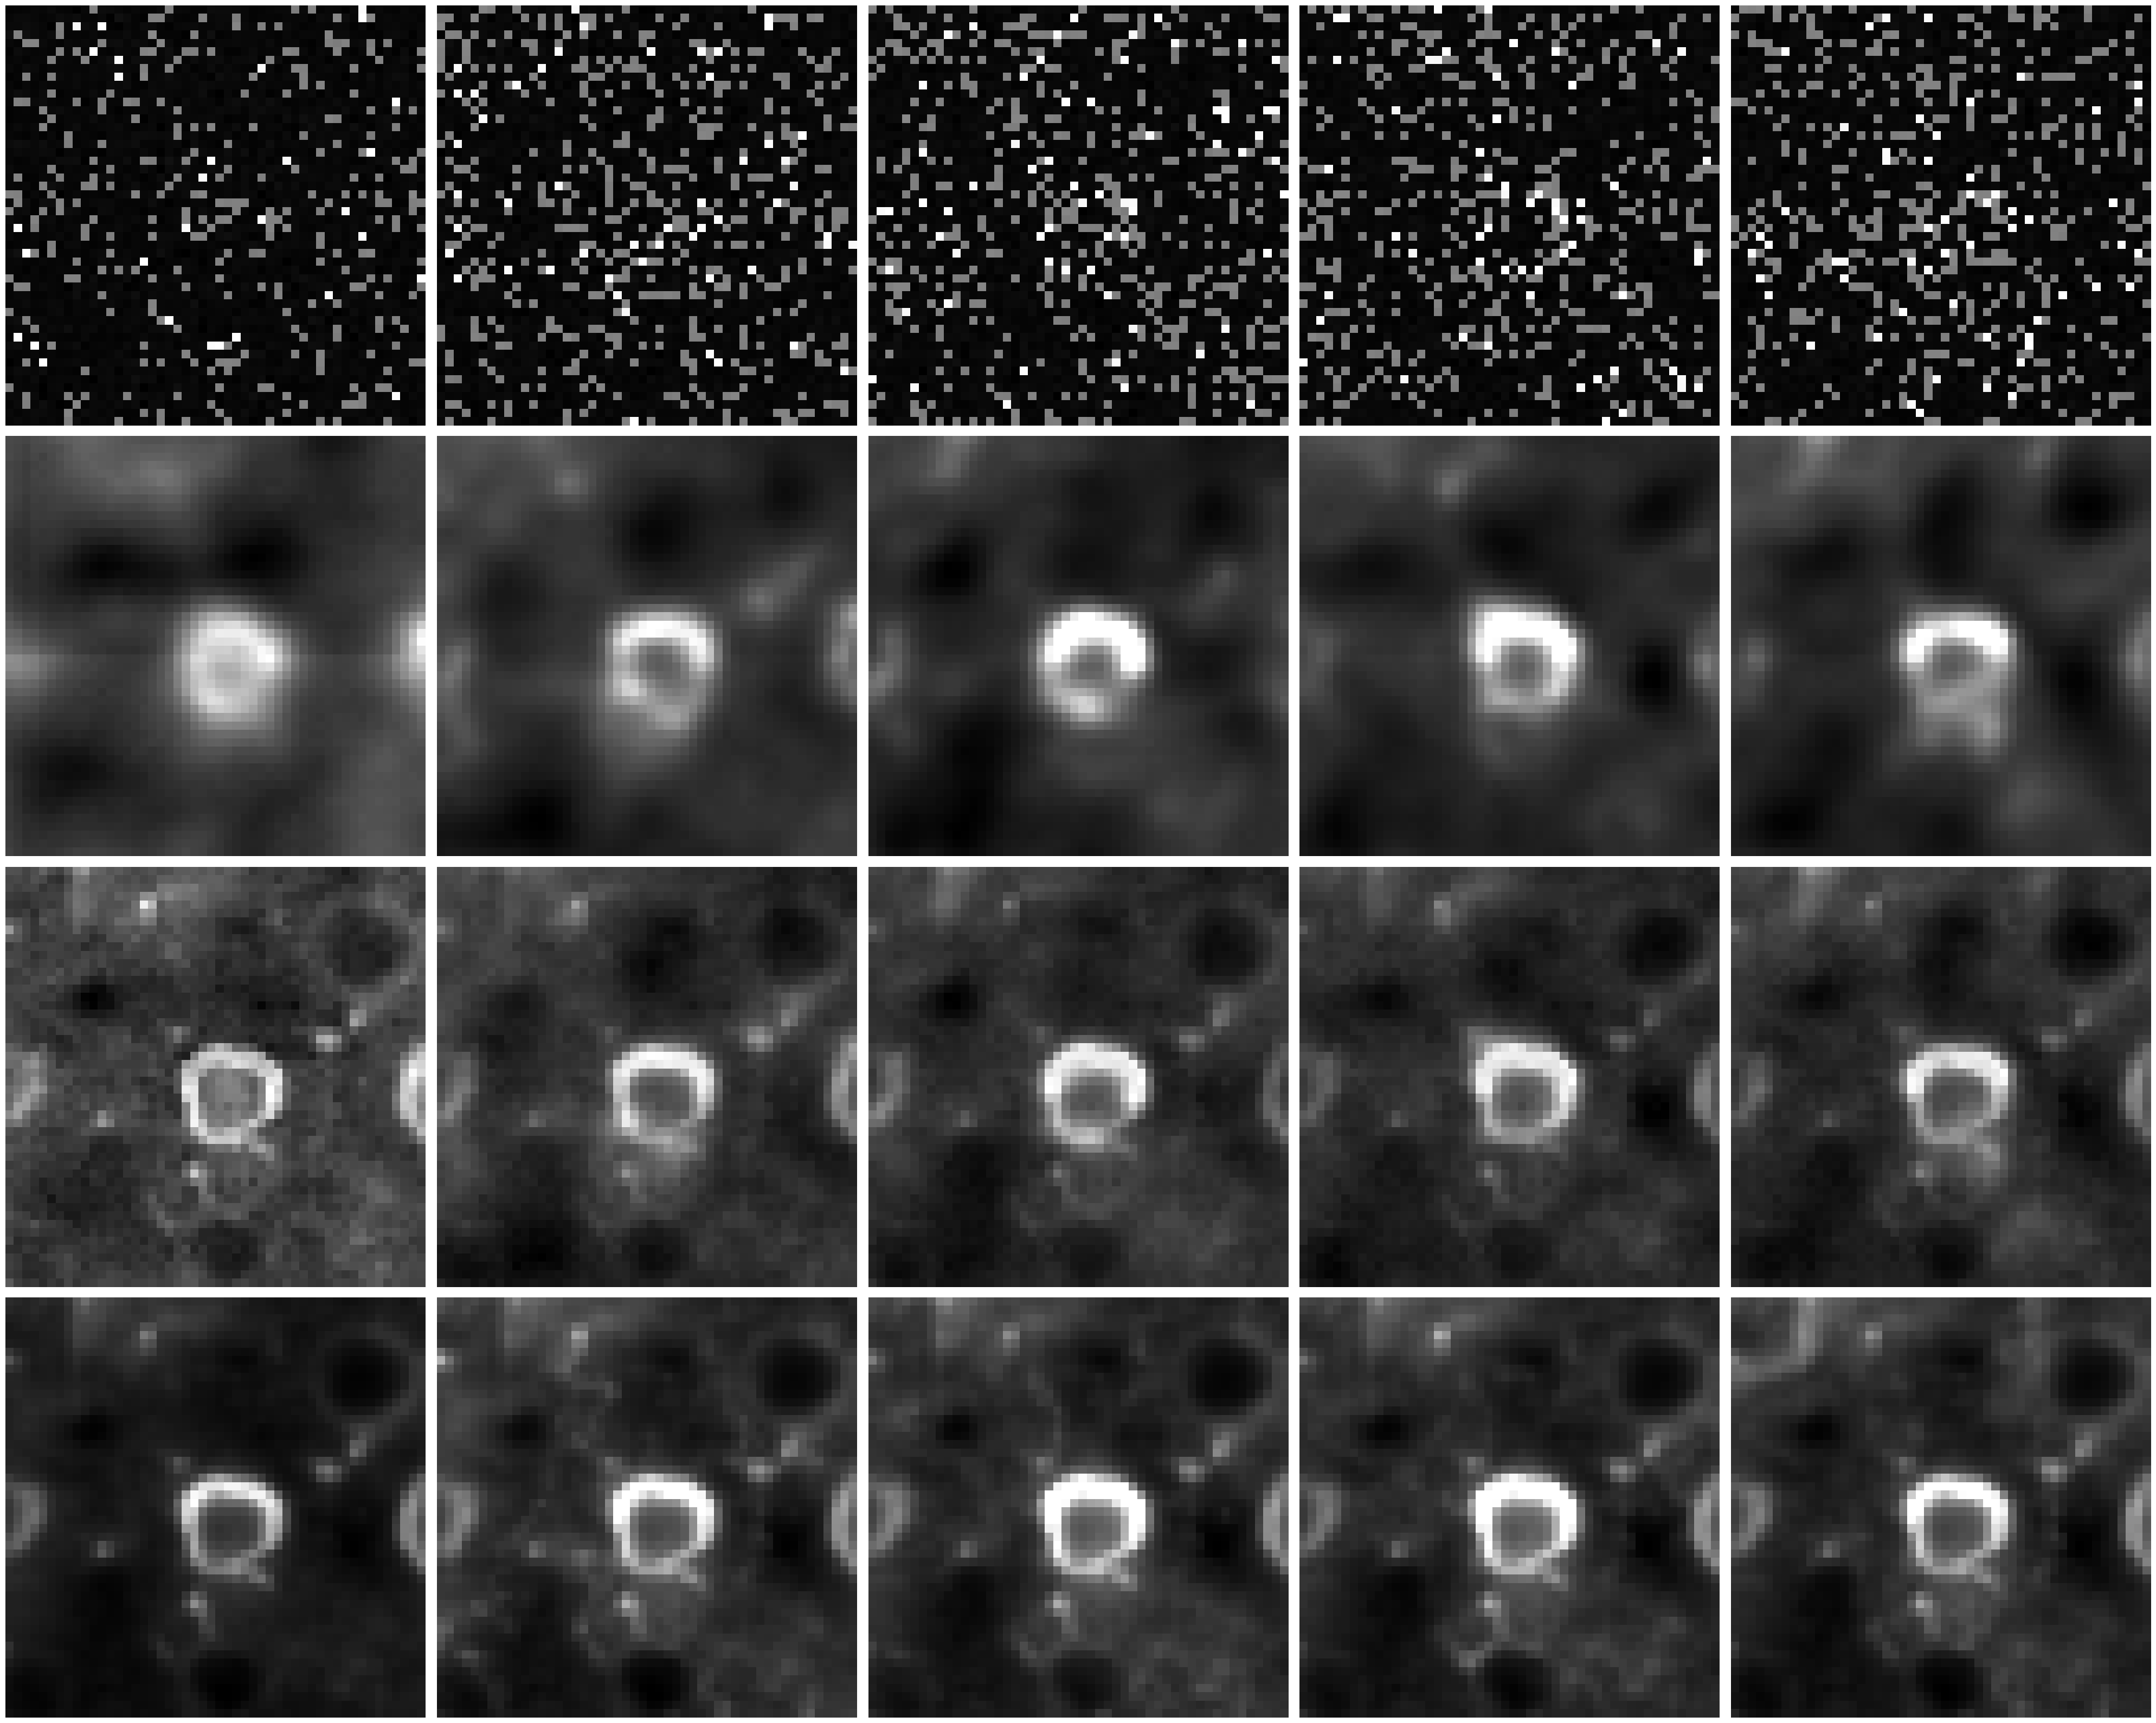

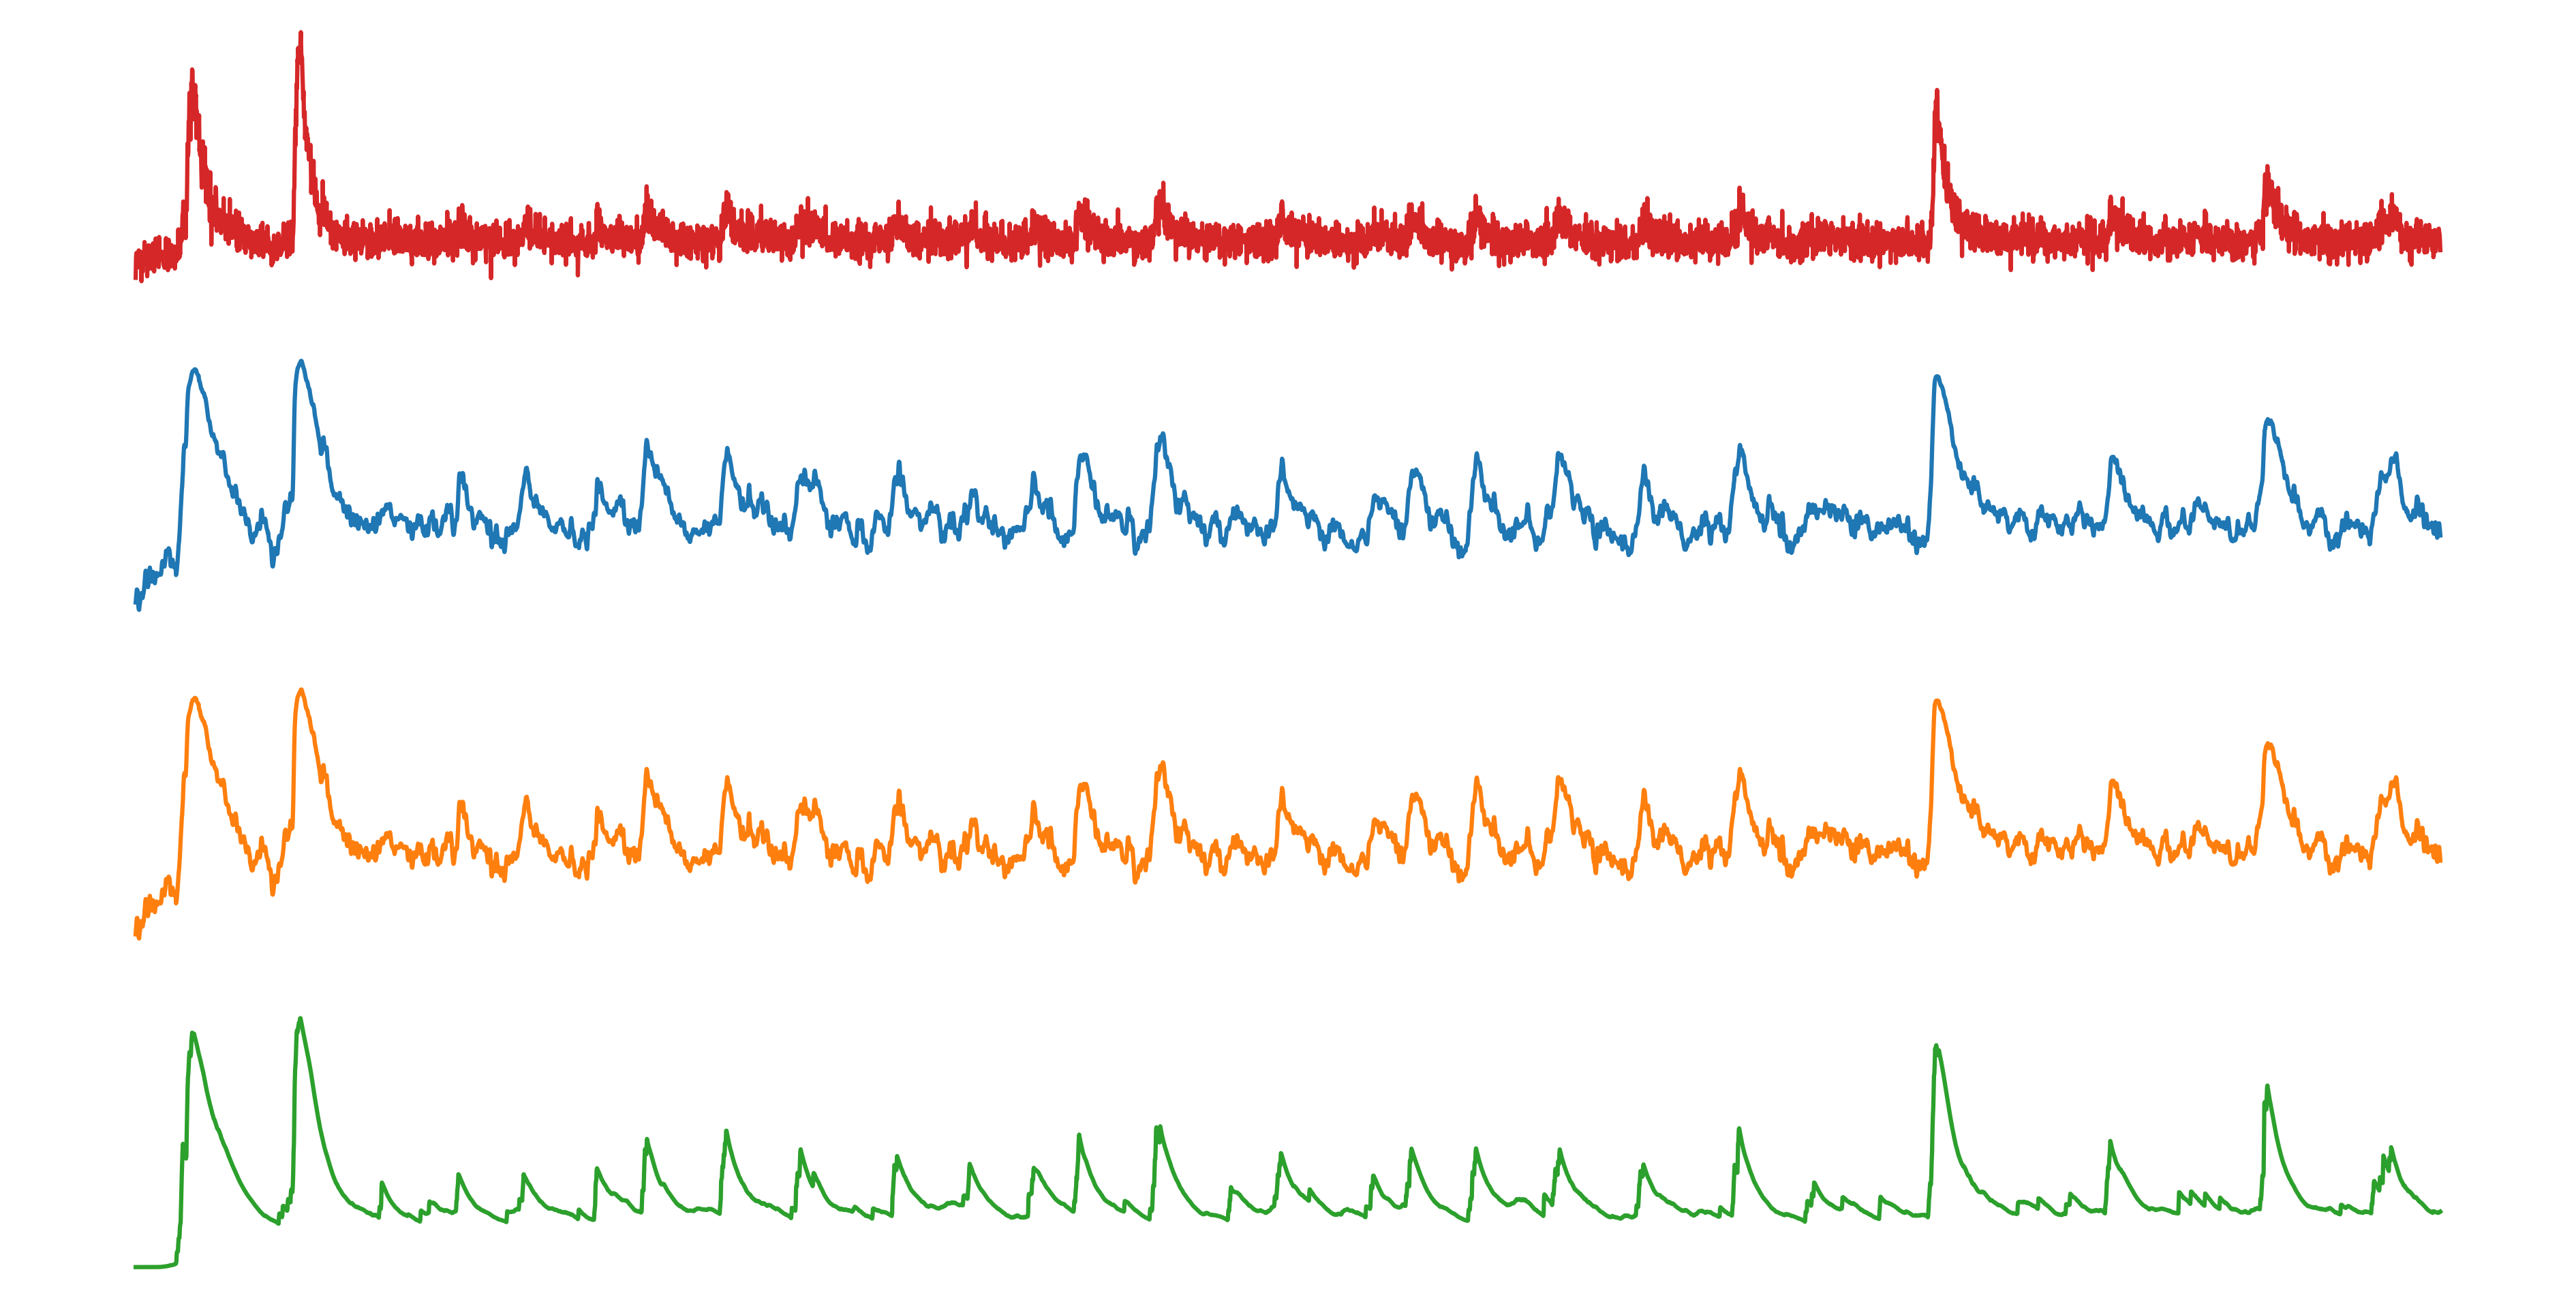

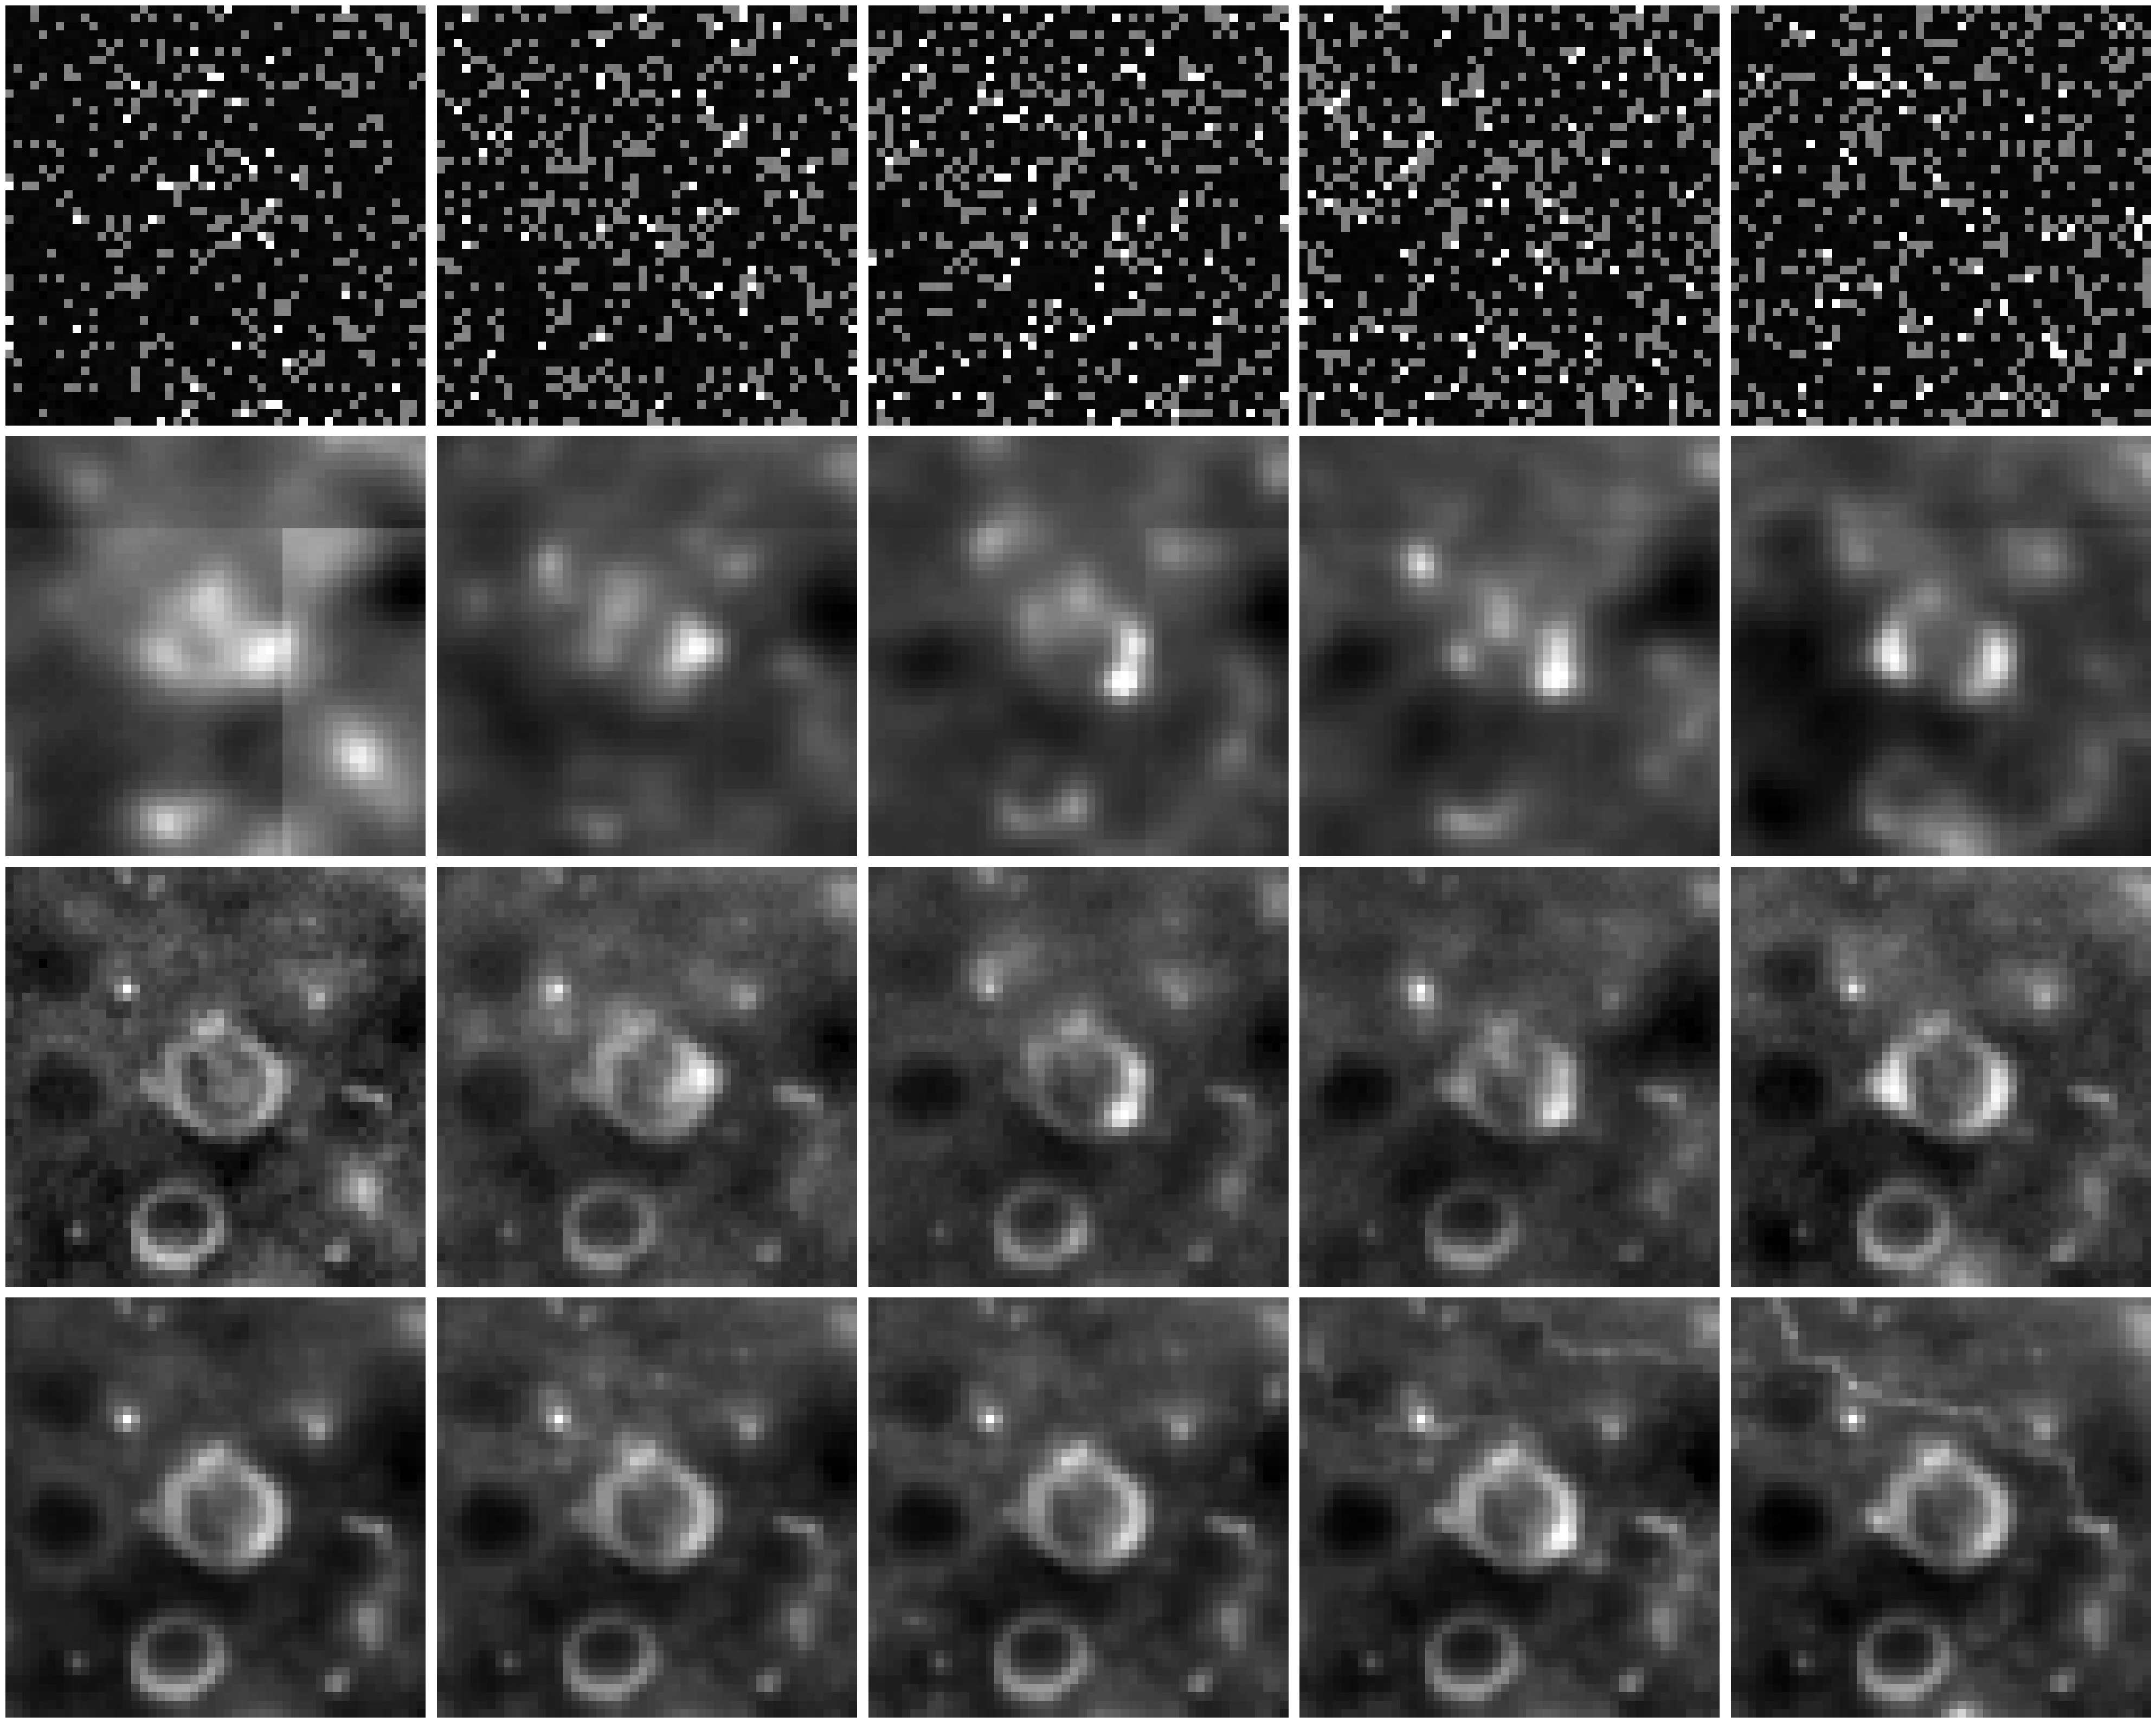

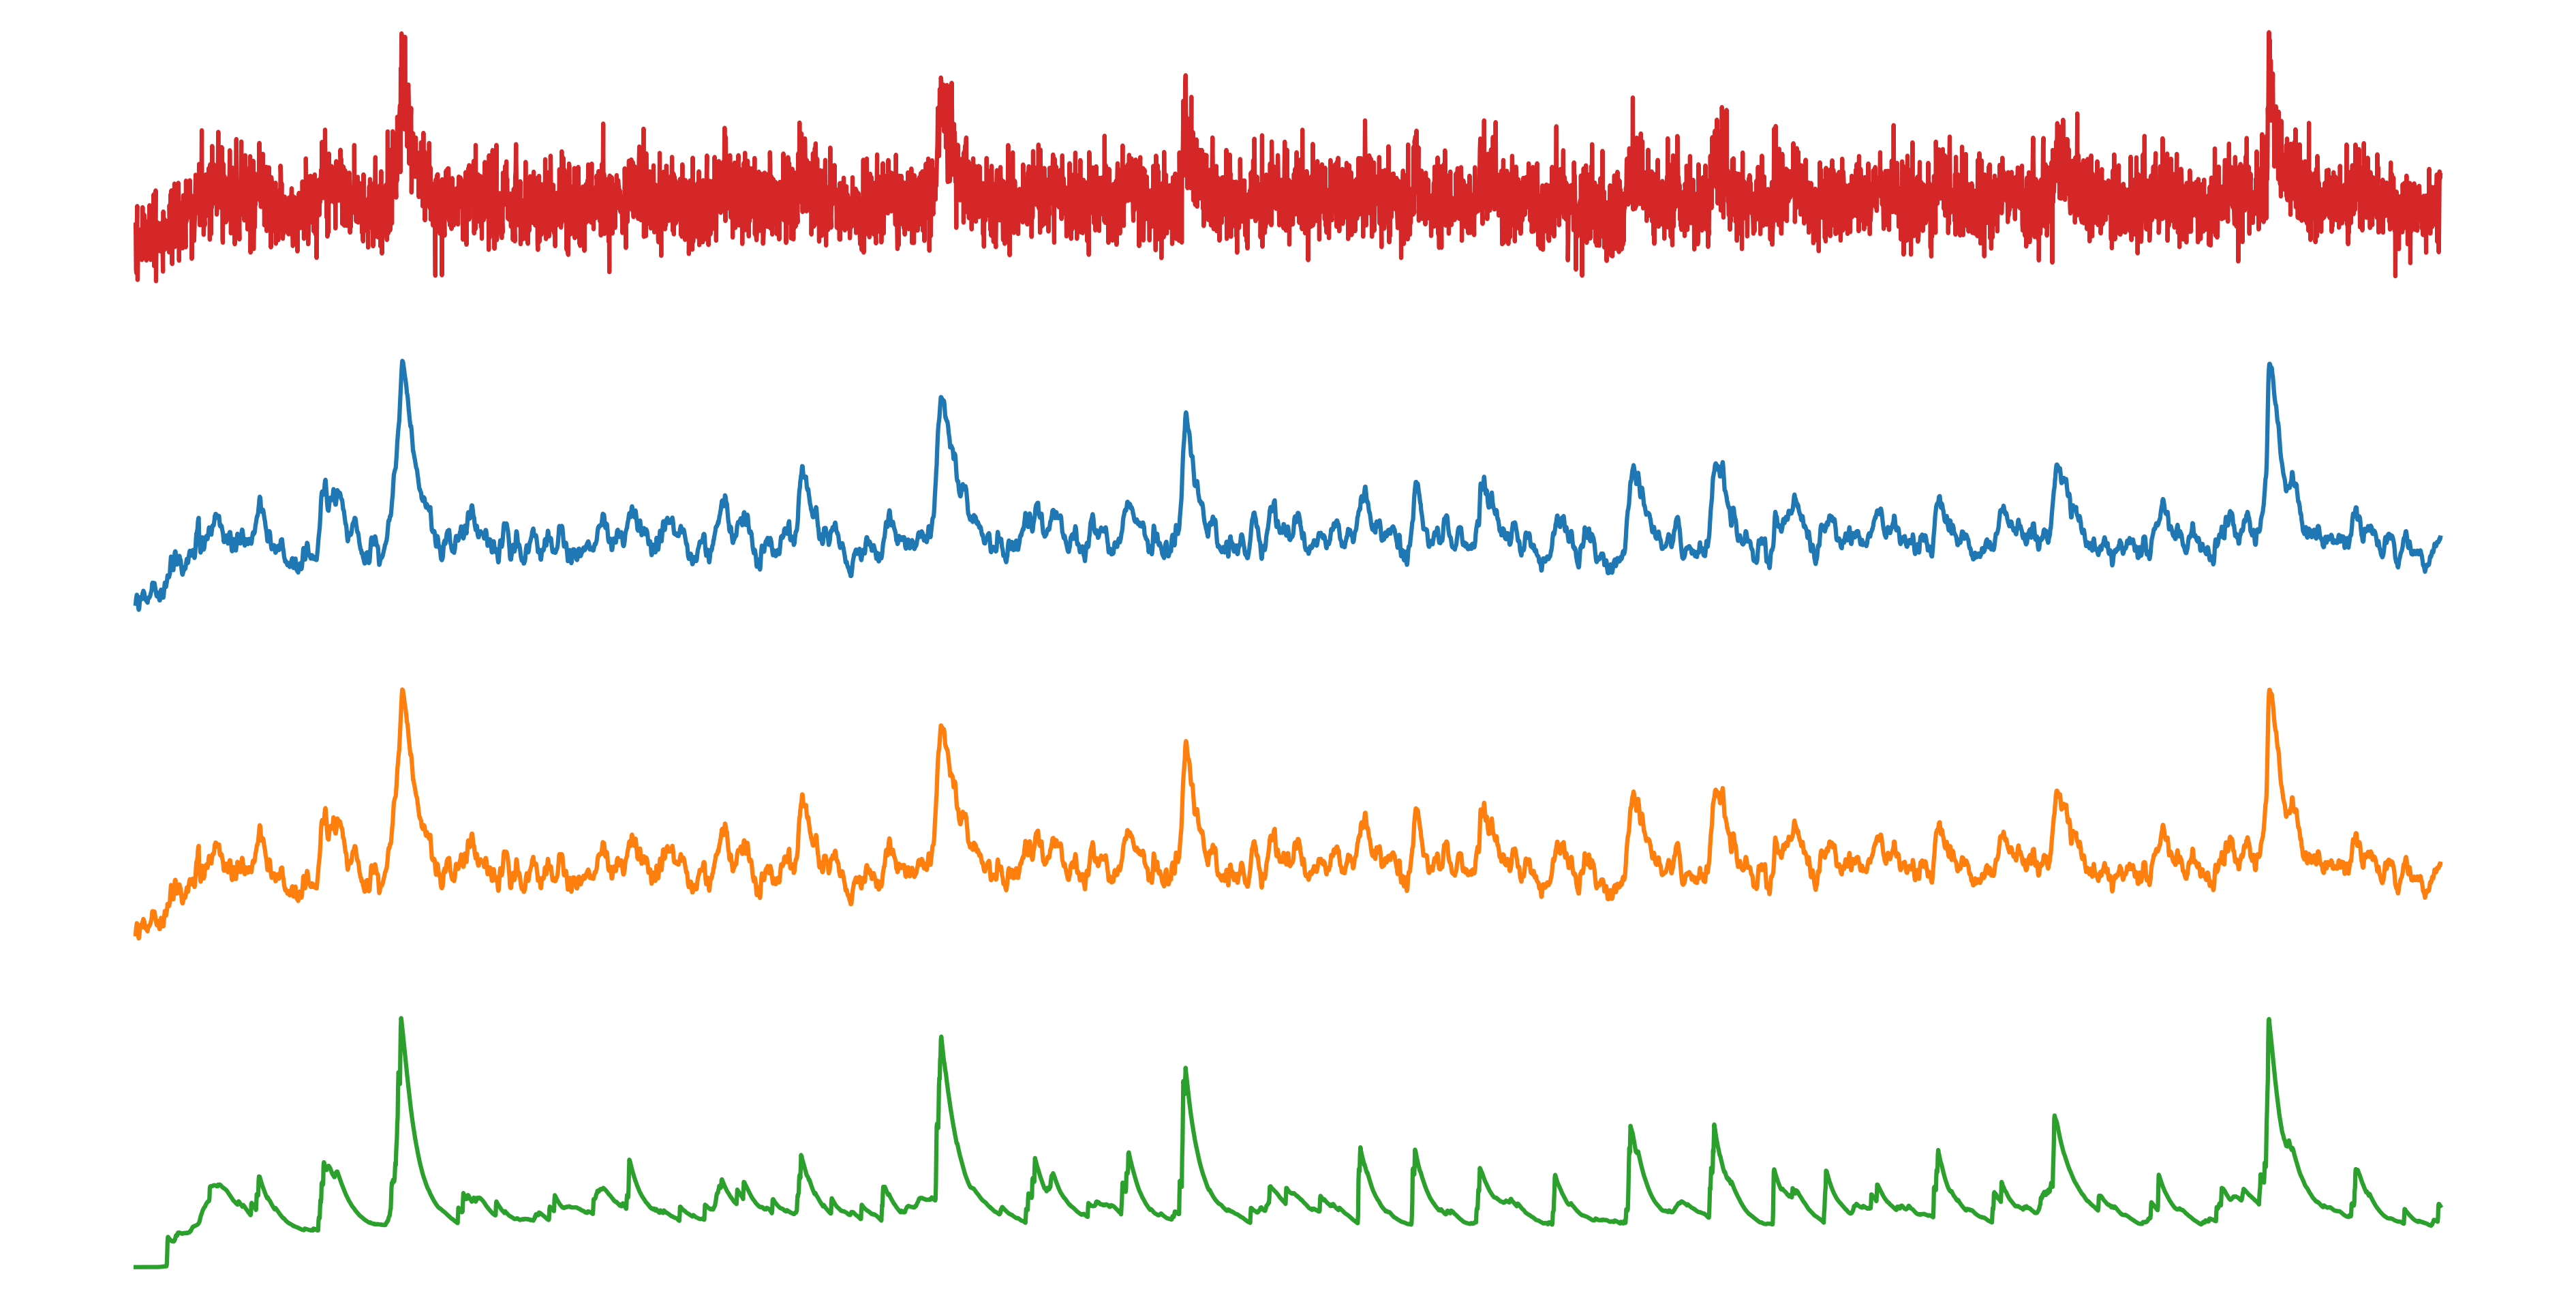

In [233]:
for roi_idx in [8, 11, 16, 21]:
    roi = gt_rois[roi_idx]
    neuron_x = roi2crop(x, roi)
    neuron_deepcad = roi2crop(y_dcad, roi)
    neuron_f2c = roi2crop(y_f2c, roi)
    neuron_gt = roi2crop(gt, roi)
    imshow(
        [neuron_x[i] for i in range(0, 5000, 1000)]
        + [neuron_deepcad[i] for i in range(0, 5000, 1000)]
        + [neuron_f2c[i] for i in range(0, 5000, 1000)]
        + [neuron_gt[i] for i in range(0, 5000, 1000)],
        size=8,
        cols=5,
    )
    neuron_trace_x = get_traces(x, [roi])[0]
    neuron_trace_deepcad = get_traces(y_dcad, [roi])[0]
    neuron_trace_f2c = get_traces(y_f2c, [roi])[0]
    neuron_trace_gt = get_traces(gt, [roi])[0]
    fig, axs = plt.subplots(4, 1, figsize=(16, 8), dpi=300)
    pd.Series(neuron_trace_x).plot(ax=axs[0], color="tab:red")
    pd.Series(neuron_trace_deepcad).plot(ax=axs[1], color="tab:blue")
    pd.Series(neuron_trace_f2c).plot(ax=axs[2], color="tab:orange")
    pd.Series(neuron_trace_gt).plot(ax=axs[3], color="tab:green")
    for ax in axs:
        ax.set_axis_off()


## One ROI analyzer

In [31]:
roi = gt_rois[random.randrange(len(gt_rois))]
traces_x = get_traces_for_one_roi(x, roi)
traces_dcad = get_traces_for_one_roi(y_dcad, roi)
traces_f2c = get_traces_for_one_roi(y_f2c, roi)
traces_gt = get_traces_for_one_roi(gt, roi)

In [23]:
f"{np.mean(np.abs(traces_dcad - traces_gt)):.3f}, {np.mean(np.abs(traces_f2c - traces_gt)):.3f}"

'0.051, 0.057'

Noisy input


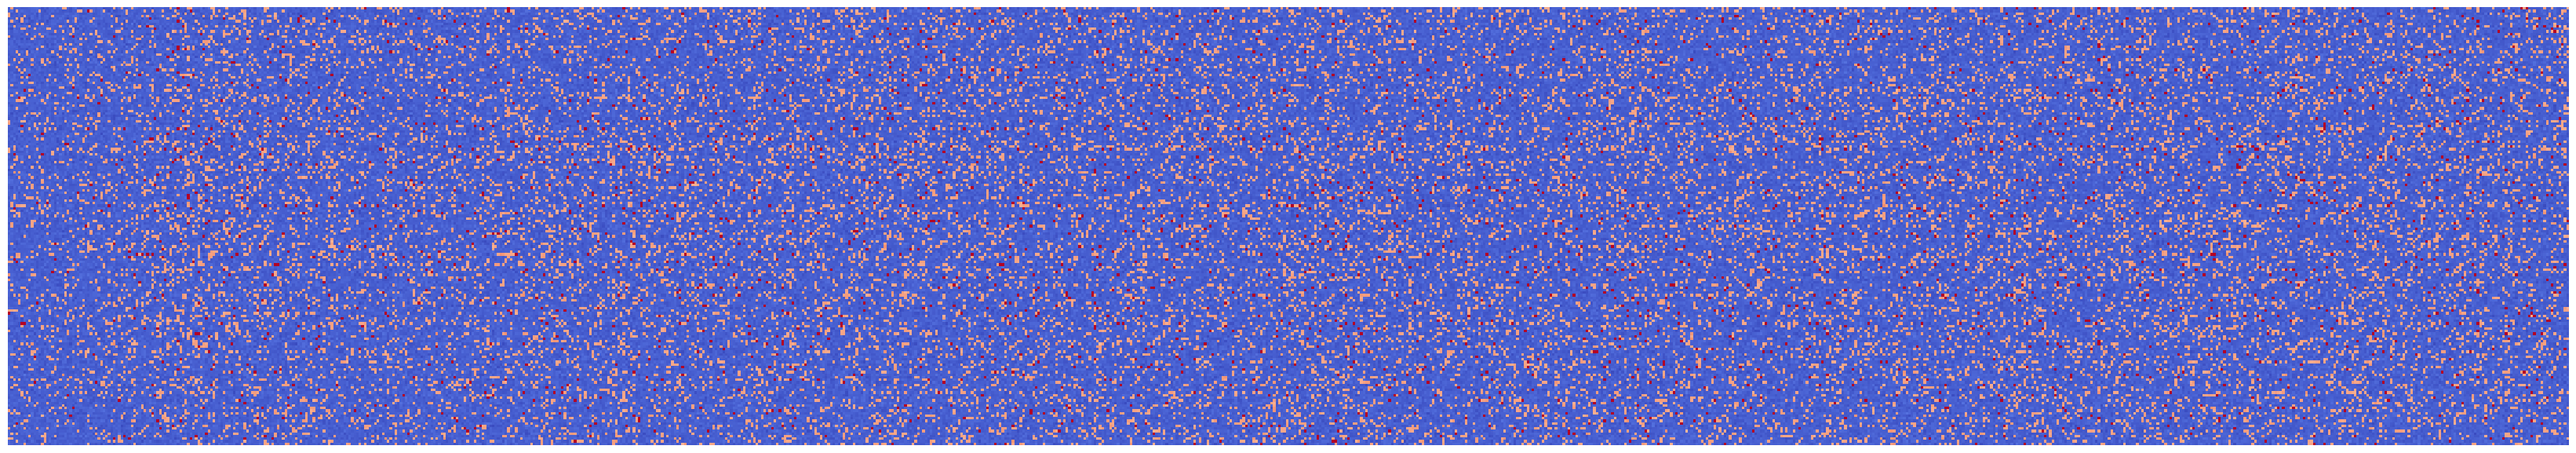

DeepCAD-RT


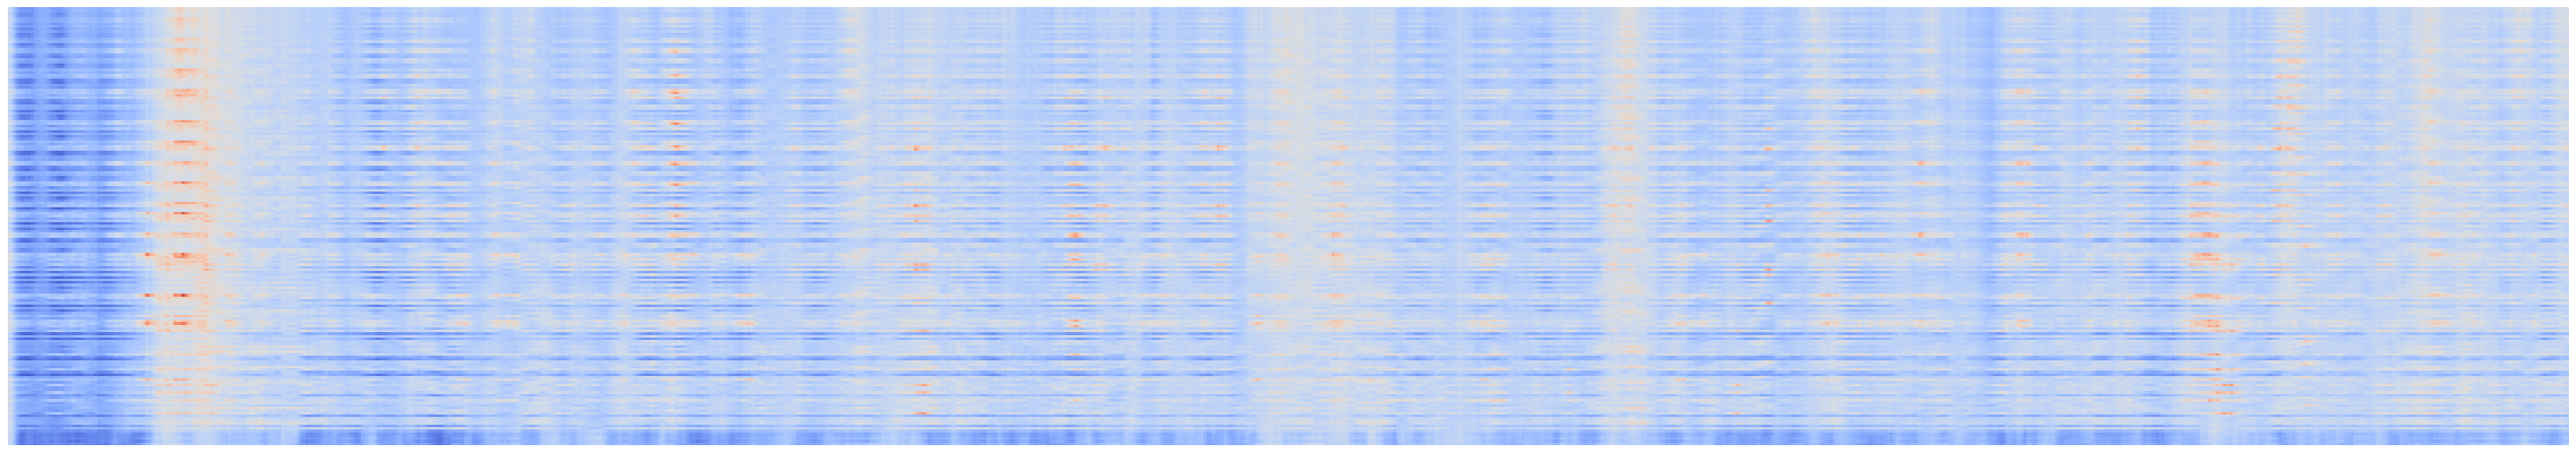

Freq2Clean


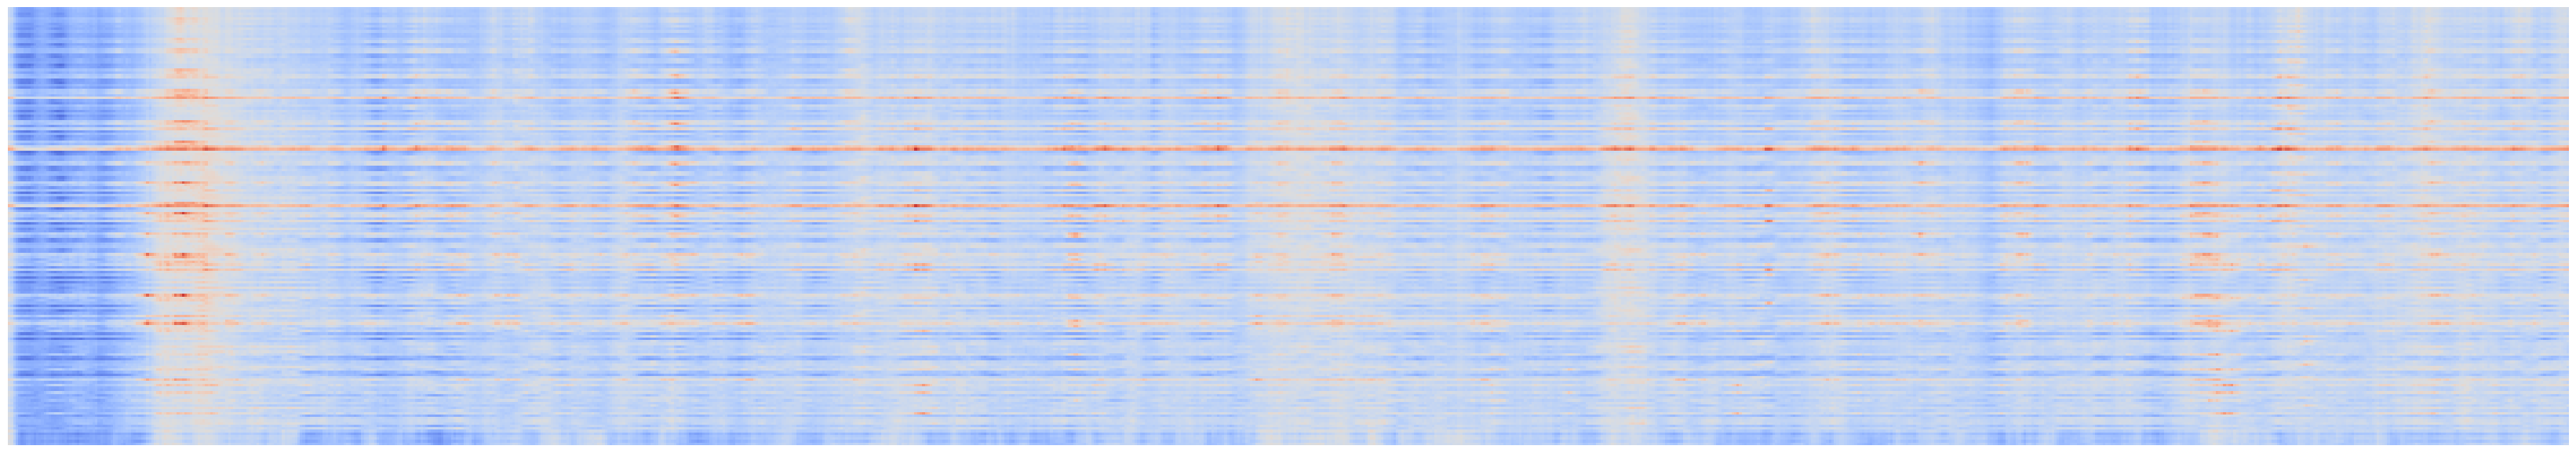

Ground Truth


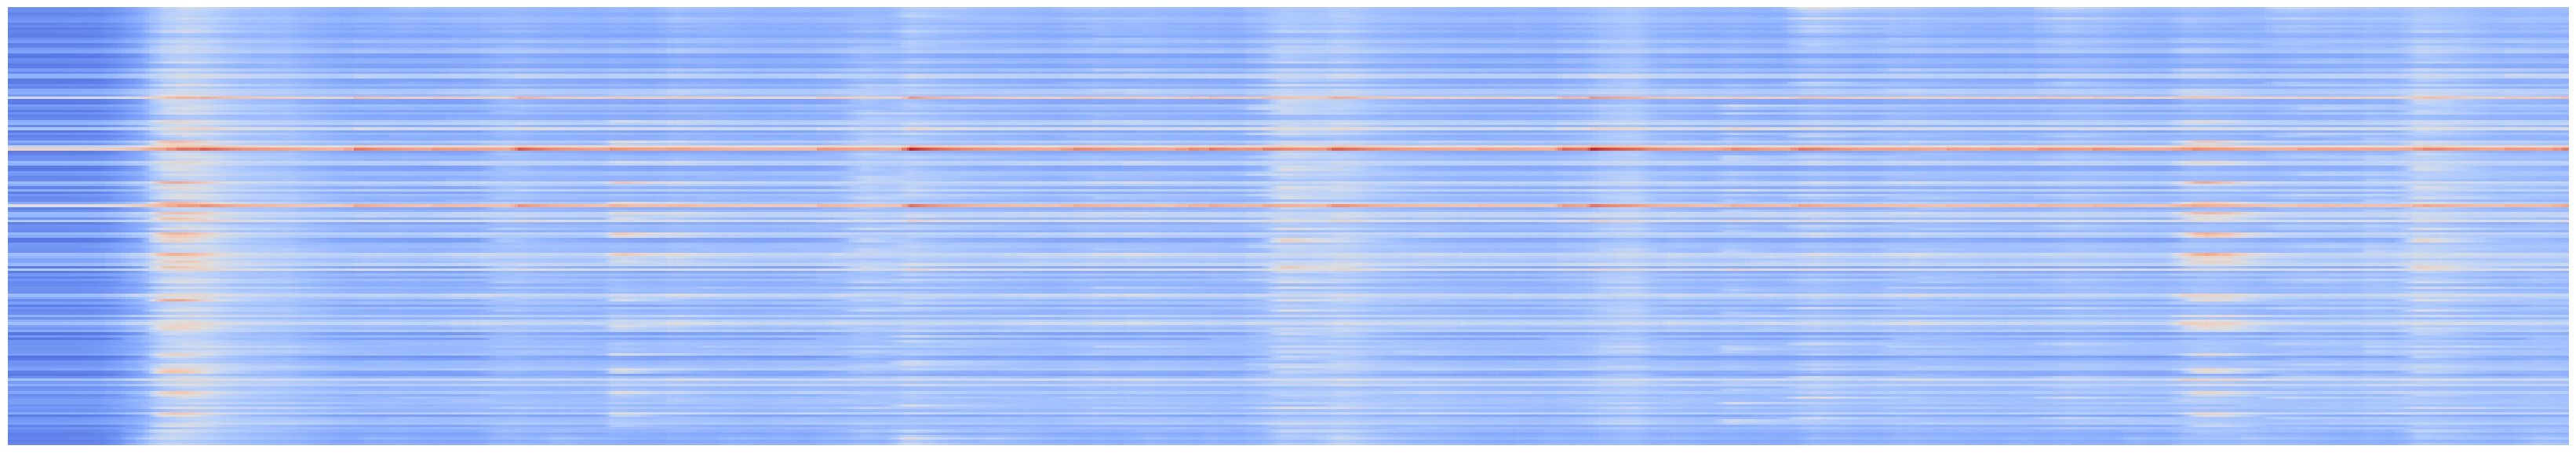

In [ ]:
max_t = 3_000
step = 3
cmap = "coolwarm"
vrange = (0, 0.7)

cprint("green:Noisy input")
imshow(traces_x[:, :max_t:step], size=40, cmap=cmap, vrange=vrange)

cprint("green:DeepCAD-RT")
imshow(traces_dcad[:, :max_t:step], size=40, cmap=cmap, vrange=vrange)

cprint("green:Freq2Clean")
imshow(traces_f2c[:, :max_t:step], size=40, cmap=cmap, vrange=vrange)

cprint("green:Ground Truth")
imshow(traces_gt[:, :max_t:step], size=40, cmap=cmap, vrange=vrange)